In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Literal
import matplotlib.patches as mpatches
import seaborn as sns
 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.neural_network import MLPClassifier
 
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
#%pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [125]:
# Set plotting style
plt.rcParams.update({
    "grid.linewidth":   0.5,
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"
PALETTE = [BLUE, TEAL, AMBER, CORAL, PURPLE, GRAY,
           "#639922","#BA7517","#185FA5","#3B6D11"]

In [126]:
#file_path = r""
df = pd.read_csv("dataset_mood_smartphone.csv")

In [127]:
# Add date and hour only columns 
df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["time"].dt.hour
df.head()

,Unnamed: 0,id,time,variable,value,date,hour
0,1,AS14.01,2014-02-26 13:00:00,mood,6.0,2014-02-26,13
1,2,AS14.01,2014-02-26 15:00:00,mood,6.0,2014-02-26,15
2,3,AS14.01,2014-02-26 18:00:00,mood,6.0,2014-02-26,18
3,4,AS14.01,2014-02-26 21:00:00,mood,7.0,2014-02-26,21
4,5,AS14.01,2014-02-27 09:00:00,mood,6.0,2014-02-27,9


## Exploratory Data Analysis

### 1A & 1B

In [128]:
print("Number of observations x Number of columns:", df.shape)
print("Earliest timestamp:", df['time'].min())
print("Latest timestamp", df['time'].max())
print("Unique users:", df['id'].nunique())
print("Unique variables:", df['variable'].nunique())
print("Total missing values (in value column):", df['value'].isnull().sum())

Number of observations x Number of columns: (376912, 7)
Earliest timestamp: 2014-02-17 07:00:52.197000
Latest timestamp 2014-06-09 00:00:00
Unique users: 27
Unique variables: 19
Total missing values (in value column): 202


In [129]:
grouped = df.groupby("variable")["value"]
# Total count and missing count per variable
total_per_variable = grouped.count()
missing_per_variable = grouped.size() - grouped.count()
missing_pct = (missing_per_variable / (missing_per_variable + total_per_variable)) * 100

stats = grouped.describe().rename(columns={"50%": "median"})
stats["missing"] = missing_per_variable
stats["missing %"] = missing_pct.round(1).fillna(100.0)
stats
## remove negative values
## for Nas in arousal and valence, wait until we impute

,count,mean,std,min,25%,median,75%,max,missing,missing %
variable,,,,,,,,,,
activity,22965.0,0.115958,0.186946,0.000,0.00000,0.021739,0.158333,1.000,0,0.0
appCat.builtin,91288.0,18.538262,415.989243,-82798.871,2.02000,4.038000,9.922000,33960.246,0,0.0
appCat.communication,74276.0,43.343792,128.912750,0.006,5.21800,16.225500,45.475750,9830.777,0,0.0
appCat.entertainment,27125.0,37.576480,262.960476,-0.011,1.33400,3.391000,14.922000,32148.677,0,0.0
appCat.finance,939.0,21.755251,39.218361,0.131,4.07200,8.026000,20.155000,355.513,0,0.0
appCat.game,813.0,128.391615,327.145246,1.003,14.14800,43.168000,123.625000,5491.793,0,0.0
appCat.office,5642.0,22.578892,449.601382,0.003,2.00400,3.106000,8.043750,32708.818,0,0.0
appCat.other,7650.0,25.810839,112.781355,0.014,7.01900,10.028000,16.829250,3892.038,0,0.0
appCat.social,19145.0,72.401906,261.551846,0.094,9.03000,28.466000,75.372000,30000.906,0,0.0


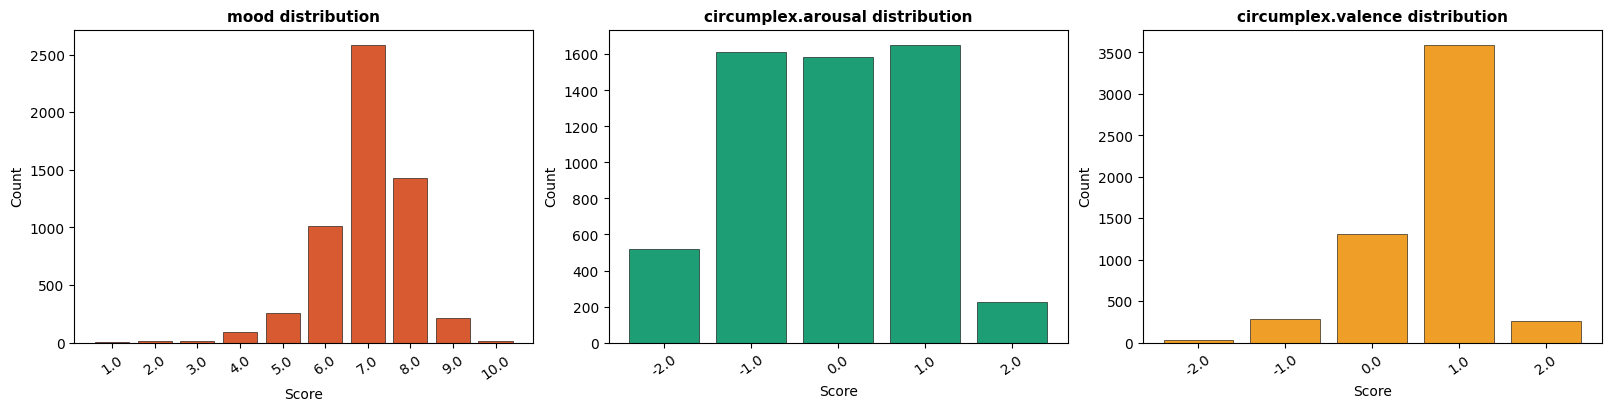

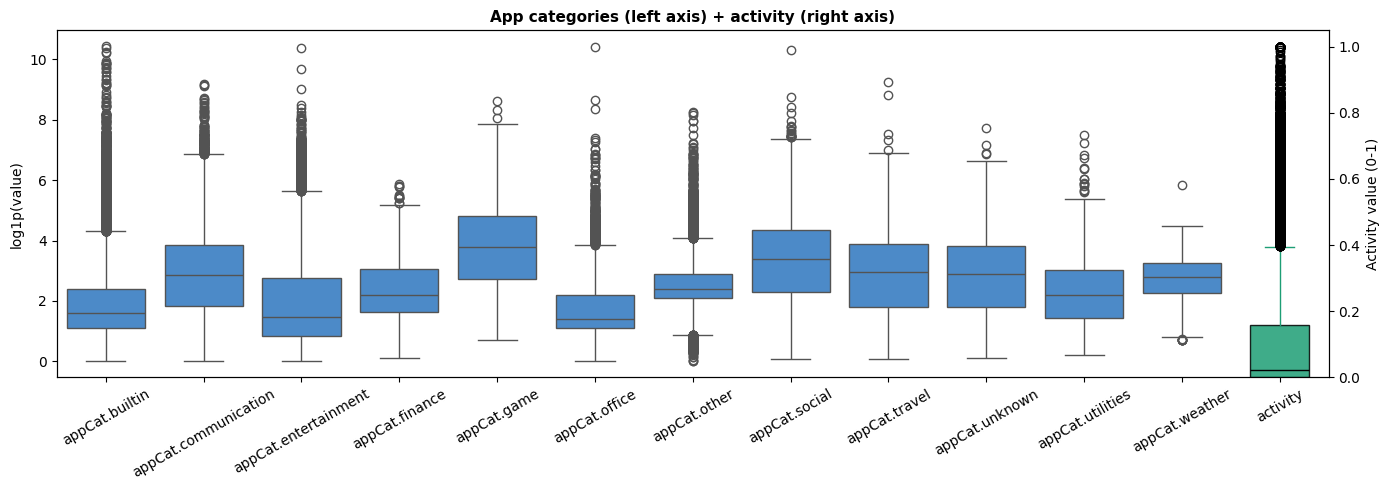

In [130]:
# Preprocessing-stage distribution overview
# Figure 1: categorical-style bar plots for mood, arousal, valence
# Figure 2: boxplots for activity and app categories together

cat_vars = ["mood", "circumplex.arousal", "circumplex.valence"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

for ax, var, color in zip(axes, cat_vars, [CORAL, TEAL, AMBER]):
    vals = df.loc[df["variable"].eq(var), "value"].dropna()
    counts = vals.value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor="black", linewidth=0.4)
    ax.set_title(f"{var} distribution")
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=35)

plt.show()
# maybe activity on its own, since btw 0 and 1
appcat_data = df[
    df["variable"].str.startswith("appCat.")
    & df["value"].notna()
    & (df["value"] >= 0)
].copy()
activity_data = df[
    df["variable"].eq("activity")
    & df["value"].notna()
    & (df["value"] >= 0)
].copy()

appcat_data["log_value"] = np.log1p(appcat_data["value"])

appcat_order = sorted(appcat_data["variable"].unique())
activity_position = len(appcat_order)

fig, ax1 = plt.subplots(figsize=(14, 5))
sns.boxplot(data=appcat_data, x="variable", y="log_value", order=appcat_order, color=BLUE, ax=ax1)
ax1.set_ylabel("log1p(value)")
ax1.set_xlabel("")
ax1.set_title("App categories (left axis) + activity (right axis)")

ax2 = ax1.twinx()
ax2.boxplot(
    [activity_data["value"].values],
    positions=[activity_position],
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor=TEAL, alpha=0.85),
    medianprops=dict(color="black"),
    whiskerprops=dict(color=TEAL),
    capprops=dict(color=TEAL),
)
ax2.set_ylabel("Activity value (0-1)")
ax2.set_ylim(0, 1.05)
ax2.grid(False)

xticks = list(range(len(appcat_order))) + [activity_position]
xlabels = appcat_order + ["activity"]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xlabels, rotation=30)
ax1.set_xlim(-0.5, activity_position + 0.5)

plt.tight_layout()
plt.show()

In [131]:
circ = df[df["variable"].isin(["circumplex.arousal", "circumplex.valence"])].copy()

for var in ["circumplex.arousal", "circumplex.valence"]:
    var_rows = circ[circ["variable"] == var].copy()
    daily = var_rows.groupby(["id", "date"])["value"].agg(
        total_rows="size",
        missing_rows=lambda s: s.isna().sum(),
        present_rows=lambda s: s.notna().sum(),
    )

    mixed_days = daily[(daily["missing_rows"] > 0) & (daily["present_rows"] > 0)]
    missing_only_days = daily[(daily["missing_rows"] > 0) & (daily["present_rows"] == 0)]

    print(f"{var}: days with at least one missing row = {daily['missing_rows'].gt(0).sum()}")
    print(f"{var}: days with both missing and present rows on the same day = {len(mixed_days)}")
    print(f"{var}: days where all rows for that variable are missing = {len(missing_only_days)}")

    if len(missing_only_days) > 0:
        print(f"\nSample fully missing days for {var}:")
        display(missing_only_days.reset_index().head(10))

        # Check whether values are present on the previous 2 and next 2 days.
        checks = []
        for r in missing_only_days.reset_index()[["id", "date"]].itertuples(index=False):
            pid = r.id
            dt = r.date

            row = {"id": pid, "date": dt}
            all_neighbors_present = True

            for offset in [-1, 1]:
                neigh_date = dt + pd.Timedelta(days=offset)
                has_present = False

                if (pid, neigh_date) in daily.index:
                    has_present = daily.loc[(pid, neigh_date), "present_rows"] > 0

                row[f"day_{offset:+d}"] = bool(has_present)
                all_neighbors_present = all_neighbors_present and bool(has_present)

            row["prev_next_present"] = all_neighbors_present
            checks.append(row)

        neigh_check = pd.DataFrame(checks)
        print(
            f"{var}: fully missing days with present values on previous and next day = "
            f"{int(neigh_check['prev_next_present'].sum())}/{len(neigh_check)}"
        )
        print(f"\nSample neighbor-presence check for {var}:")
        display(neigh_check.head(10))
        # will be imputed

circumplex.arousal: days with at least one missing row = 45
circumplex.arousal: days with both missing and present rows on the same day = 45
circumplex.arousal: days where all rows for that variable are missing = 0
circumplex.valence: days with at least one missing row = 119
circumplex.valence: days with both missing and present rows on the same day = 117
circumplex.valence: days where all rows for that variable are missing = 2

Sample fully missing days for circumplex.valence:


,id,date,total_rows,missing_rows,present_rows
0,AS14.24,2014-05-10,4,4,0
1,AS14.24,2014-06-07,1,1,0


circumplex.valence: fully missing days with present values on previous and next day = 2/2

Sample neighbor-presence check for circumplex.valence:


,id,date,day_-1,day_+1,prev_next_present
0,AS14.24,2014-05-10,True,True,True
1,AS14.24,2014-06-07,True,True,True


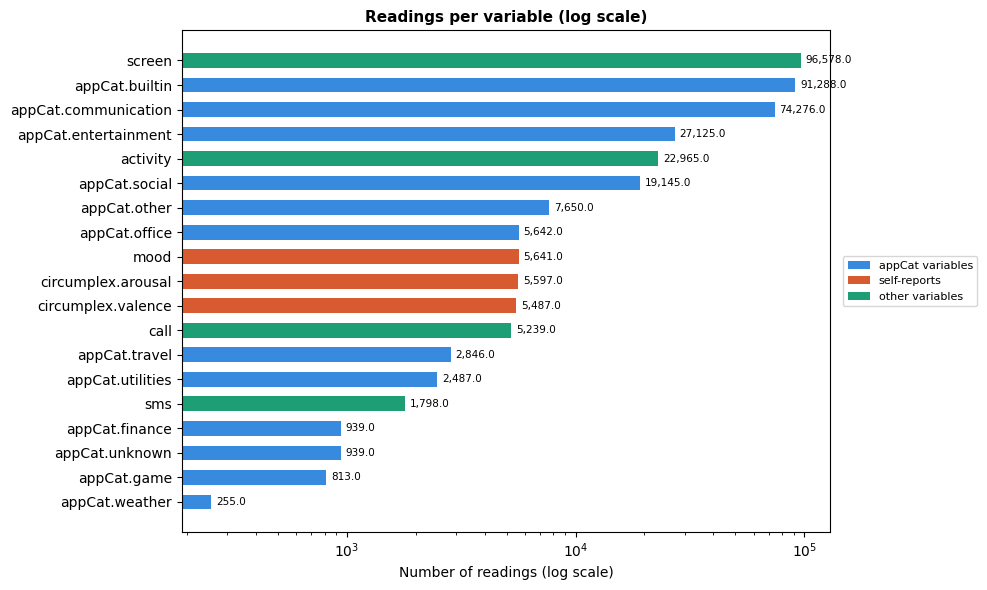

In [132]:
counts = stats["count"].sort_values(ascending=True)
colors_bar = [
    BLUE if "appCat" in v else
    CORAL if v in ("mood", "circumplex.arousal", "circumplex.valence") else
    TEAL
    for v in counts.index
]

plt.figure(figsize=(10, 6))
plt.barh(counts.index, counts.values, height=0.6, color=colors_bar)
plt.xscale("log")
plt.xlabel("Number of readings (log scale)")
plt.title("Readings per variable (log scale)")
plt.legend(
    handles=[
        mpatches.Patch(facecolor=BLUE, label="appCat variables"),
        mpatches.Patch(facecolor=CORAL, label="self-reports"),
        mpatches.Patch(facecolor=TEAL, label="other variables"),
    ],
    fontsize=8,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    frameon=True,
)
for value, variable in zip(counts.values, counts.index):
    plt.text(value * 1.05, variable, f"{value:,}", va="center", fontsize=7.5)
plt.tight_layout()
plt.show()

# Sensor data (screen, appCat) is sampled far more than self-reports (mood, arousal). Maybe table is enough to show this
# Need to understand how to handle this when we will pivot the data to wide format and have missing values for self-reports.

In [133]:
# Check and remove negative values for appCat.builtin (before aggregating to pivot)
is_builtin = df["variable"].eq("appCat.builtin")
is_negative_builtin = is_builtin & (df["value"] < 0)

print("Negative appCat.builtin rows:", int(is_negative_builtin.sum()))
df = df.loc[~is_negative_builtin].copy()
print("Remaining negative appCat.builtin rows:", int(((df["variable"] == "appCat.builtin") & (df["value"] < 0)).sum()))

Negative appCat.builtin rows: 3
Remaining negative appCat.builtin rows: 0


In [134]:
# Check and remove negative values for appCat.entertainment
is_entr = df["variable"].eq("appCat.entertainment")
is_negative_entr = is_entr & (df["value"] < 0)

print("Negative appCat.entertainment rows:", int(is_negative_entr.sum()))
df = df.loc[~is_negative_entr].copy()
print("Remaining negative appCat.entertainment rows:", int(((df["variable"] == "appCat.entertainment") & (df["value"] < 0)).sum()))

Negative appCat.entertainment rows: 1
Remaining negative appCat.entertainment rows: 0


In [135]:
# Creating wide format dataset
mood_data = (df[df["variable"].isin(["mood", "circumplex.arousal", "circumplex.valence", "activity"])]).sort_values(by=["id", "time"])
mood_pivot = mood_data.pivot_table(
    index=["id", "date"], 
    columns="variable", 
    values="value", 
    aggfunc=["mean", "max", "min", "std", "count"] #stats for the daily averages
)
mood_pivot.columns = [f"{var}_{stat}" for stat, var in mood_pivot.columns]
mood_pivot = mood_pivot.reset_index()

mood_pivot.head()
## see that first user has first observation 26 Febr and third one 20 March

,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,circumplex.valence_min,mood_min,activity_std,circumplex.arousal_std,circumplex.valence_std,mood_std,activity_count,circumplex.arousal_count,circumplex.valence_count,mood_count
0,AS14.01,2014-02-26,NaN,-0.25,0.750000,6.250000,NaN,1.0,1.0,7.0,...,0.0,6.0,NaN,0.957427,0.500000,0.500000,NaN,4.0,4.0,4.0
1,AS14.01,2014-02-27,NaN,0.00,0.333333,6.333333,NaN,1.0,1.0,7.0,...,0.0,6.0,NaN,1.732051,0.577350,0.577350,NaN,3.0,3.0,3.0
2,AS14.01,2014-03-20,0.081548,NaN,NaN,NaN,0.091667,NaN,NaN,NaN,...,NaN,NaN,0.014310,NaN,NaN,NaN,2.0,NaN,NaN,NaN
3,AS14.01,2014-03-21,0.134050,0.20,0.200000,6.200000,0.798387,1.0,1.0,7.0,...,0.0,6.0,0.221478,0.836660,0.447214,0.447214,23.0,5.0,5.0,5.0
4,AS14.01,2014-03-22,0.236880,0.60,0.500000,6.400000,0.508475,1.0,1.0,7.0,...,-1.0,5.0,0.166143,0.894427,1.000000,0.894427,16.0,5.0,4.0,5.0


In [136]:
rec_vars = ['screen',
 'call',
 'sms',
 'appCat.builtin',
 'appCat.communication',
 'appCat.entertainment',
 'appCat.finance',
 'appCat.game',
 'appCat.office',
 'appCat.other',
 'appCat.social',
 'appCat.travel',
 'appCat.unknown',
 'appCat.utilities',
 'appCat.weather']

rec_data = (df[df["variable"].isin(rec_vars)]).sort_values(by=["id", "time"])
rec_pivot = rec_data.pivot_table(
    index=["id", "date"], 
    columns=["variable"], 
    values="value", 
    aggfunc=["sum"]
)
rec_pivot.columns = [f"{var}_{stat}" for stat, var in rec_pivot.columns]
rec_pivot = rec_pivot.reset_index()

rec_pivot.head()

,id,date,appCat.builtin_sum,appCat.communication_sum,appCat.entertainment_sum,appCat.finance_sum,appCat.game_sum,appCat.office_sum,appCat.other_sum,appCat.social_sum,appCat.travel_sum,appCat.unknown_sum,appCat.utilities_sum,appCat.weather_sum,call_sum,screen_sum,sms_sum
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,2.0
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,3.0
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [137]:
df_wide = mood_pivot.merge(rec_pivot, on=["id", "date"], how="outer")
df_wide["day_of_week"] = df_wide["date"].dt.day_name()
df_wide["month"] = df_wide["date"].dt.month_name()
df_wide["weekend"] = df_wide["day_of_week"].isin(["Saturday", "Sunday"])
print("Wide shape:", df_wide.shape)
df_wide.head()

Wide shape: (1973, 40)


,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,appCat.travel_sum,appCat.unknown_sum,appCat.utilities_sum,appCat.weather_sum,call_sum,screen_sum,sms_sum,day_of_week,month,weekend
0,AS14.01,2014-02-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,Monday,February,False
1,AS14.01,2014-02-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,Tuesday,February,False
2,AS14.01,2014-02-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.0,NaN,2.0,Wednesday,February,False
3,AS14.01,2014-02-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,3.0,Thursday,February,False
4,AS14.01,2014-02-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Friday,February,False


In [138]:
gap_threshold = 3 # check gaps longer than 3 days
results = []
for part_id, group in df_wide.groupby('id'):
    valid = group[group["mood_mean"].notna()].sort_values('date')
        
    valid['gap_days'] = valid['date'].diff().dt.days
    big_gaps = valid[valid['gap_days'] > gap_threshold][['date', 'gap_days']]
    if not big_gaps.empty:
        big_gaps['id_num'] = part_id
        results.append(big_gaps)
    
pd.concat(results).sort_values(['id_num', 'date'])

,date,gap_days,id_num
26,2014-03-21,22.0,AS14.01
576,2014-03-27,12.0,AS14.12
942,2014-03-21,7.0,AS14.17


In [139]:
 # remove gaps longer than 3 days
result = []
for part_id, group in df_wide.groupby('id'):
    group = group.sort_values('date')
    valid_dates = group[group['mood_mean'].notna()]['date']
    gaps = valid_dates.diff()
    
    big_gap_dates = valid_dates[gaps.dt.days > 3]
    
    if not big_gap_dates.empty:
        cutoff = big_gap_dates.iloc[-1]
        n_before = (group['date'] < cutoff).sum()
        group = group[group['date'] >= cutoff]
        print(f"User {part_id}: remove {n_before} days before {cutoff.date()}")
    
    result.append(group)

df_consec = pd.concat(result, ignore_index=True)
print("Shape after removing gaps:", df_consec.shape)

User AS14.01: remove 26 days before 2014-03-21
User AS14.12: remove 27 days before 2014-03-27
User AS14.17: remove 29 days before 2014-03-21
Shape after removing gaps: (1891, 40)


In [140]:
# Start imputation
# create a row per each day 
df_daily = (df_consec.set_index('date')
           .groupby('id')
           .resample('D').asfreq()
           .drop(columns='id')  # removing the redundant column
           .reset_index()).copy()


/var/folders/z3/h9qtkxfd38q8llwvssylbv8h0000gn/T/ipykernel_25110/1897982857.py:5: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .resample('D').asfreq()


In [141]:
df_daily.isna().sum()

id                             0
date                           0
activity_mean                868
circumplex.arousal_mean      800
circumplex.valence_mean      802
mood_mean                    800
activity_max                 868
circumplex.arousal_max       800
circumplex.valence_max       802
mood_max                     800
activity_min                 868
circumplex.arousal_min       800
circumplex.valence_min       802
mood_min                     800
activity_std                 878
circumplex.arousal_std       825
circumplex.valence_std       829
mood_std                     825
activity_count               868
circumplex.arousal_count     800
circumplex.valence_count     800
mood_count                   800
appCat.builtin_sum           861
appCat.communication_sum     873
appCat.entertainment_sum    1206
appCat.finance_sum          1847
appCat.game_sum             1861
appCat.office_sum           1778
appCat.other_sum             936
appCat.social_sum           1068
appCat.tra

In [142]:
# fill zero for appCat vars
zero_vars = ['appCat.builtin_sum', 'appCat.communication_sum', 'appCat.entertainment_sum',
             'appCat.finance_sum', 'appCat.game_sum', 'appCat.office_sum',
             'appCat.other_sum', 'appCat.social_sum', 'appCat.travel_sum',
             'appCat.unknown_sum', 'appCat.utilities_sum', 'appCat.weather_sum',
             'call_sum', 'screen_sum', 'sms_sum']

for col in zero_vars:
    if col in df_daily.columns:
        df_daily[col] = df_daily[col].fillna(0) 

In [143]:
# check that we filled zeros for appCat variables
df_daily[zero_vars].isna().sum()

appCat.builtin_sum          0
appCat.communication_sum    0
appCat.entertainment_sum    0
appCat.finance_sum          0
appCat.game_sum             0
appCat.office_sum           0
appCat.other_sum            0
appCat.social_sum           0
appCat.travel_sum           0
appCat.unknown_sum          0
appCat.utilities_sum        0
appCat.weather_sum          0
call_sum                    0
screen_sum                  0
sms_sum                     0
dtype: int64

In [144]:
# fill for mood and circumplex vars using different methods (LOCF, feature)
target_vars = [col for col in df_daily.columns if ('mean' in col) or ('max' in col) or ('min' in col) or ('std' in col) or ('count' in col)] 
df_LOCF = df_daily.copy()
df_LOCF = df_LOCF.sort_values(['id', 'date'])
for var in target_vars:
   # limit: 3 days
   df_LOCF[var] = df_LOCF.groupby("id")[var].ffill(limit=3)

In [145]:
# method 2:interpolation
df_interpolation = df_daily.copy()
df_interpolation = df_interpolation.sort_values(['id', 'date'])
for var in target_vars:
    # two known neighbors
    df_interpolation[var] = df_interpolation.groupby("id")[var].transform(
        lambda x: x.interpolate(method='linear', limit=3, limit_direction='forward'))   

In [146]:
df_LOCF[target_vars].isna().sum()

activity_mean               840
circumplex.arousal_mean     765
circumplex.valence_mean     765
mood_mean                   765
activity_max                840
circumplex.arousal_max      765
circumplex.valence_max      765
mood_max                    765
activity_min                840
circumplex.arousal_min      765
circumplex.valence_min      765
mood_min                    765
activity_std                842
circumplex.arousal_std      772
circumplex.valence_std      772
mood_std                    772
activity_count              840
circumplex.arousal_count    765
circumplex.valence_count    765
mood_count                  765
dtype: int64

In [147]:
df_interpolation[target_vars].isna().sum()

activity_mean               840
circumplex.arousal_mean     765
circumplex.valence_mean     765
mood_mean                   765
activity_max                840
circumplex.arousal_max      765
circumplex.valence_max      765
mood_max                    765
activity_min                840
circumplex.arousal_min      765
circumplex.valence_min      765
mood_min                    765
activity_std                842
circumplex.arousal_std      772
circumplex.valence_std      772
mood_std                    772
activity_count              840
circumplex.arousal_count    765
circumplex.valence_count    765
mood_count                  765
dtype: int64

In [148]:
df_interpolation.head()

,id,date,activity_mean,circumplex.arousal_mean,circumplex.valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,appCat.travel_sum,appCat.unknown_sum,appCat.utilities_sum,appCat.weather_sum,call_sum,screen_sum,sms_sum,day_of_week,month,weekend
0,AS14.01,2014-03-21,0.134050,0.2,0.2,6.20,0.798387,1.0,1.0,7.0,...,915.445,0.000,598.754,0.000,6.0,17978.907000,0.0,Friday,March,False
1,AS14.01,2014-03-22,0.236880,0.6,0.5,6.40,0.508475,1.0,1.0,7.0,...,37.305,0.000,117.621,0.000,3.0,6142.161000,1.0,Saturday,March,True
2,AS14.01,2014-03-23,0.142741,0.2,0.8,6.80,0.313559,1.0,1.0,8.0,...,0.000,0.000,30.086,30.386,0.0,6773.832001,0.0,Sunday,March,True
3,AS14.01,2014-03-24,0.078961,0.8,0.0,6.00,0.361345,2.0,1.0,7.0,...,419.805,0.000,178.732,0.000,10.0,15047.351001,0.0,Monday,March,False
4,AS14.01,2014-03-25,0.098374,0.5,0.5,6.75,0.594828,1.0,1.0,8.0,...,0.000,235.223,222.893,0.000,0.0,21475.354999,1.0,Tuesday,March,False


In [149]:
# Clean NAs in mood_mean (self-reports), if gap is larger than 2 days
print("Number of NAs in mood_mean before dropping:", df_LOCF["mood_mean"].isnull().sum())
df_LOCF.dropna(subset=["mood_mean"], inplace=True)
print("Number of NAs in mood_mean after dropping:", df_LOCF["mood_mean"].isnull().sum())

Number of NAs in mood_mean before dropping: 765
Number of NAs in mood_mean after dropping: 0


In [150]:
# Clean NAs in mood_mean (self-reports), if gap is larger than 2 days
print("Number of NAs in mood_mean before dropping:", df_interpolation["mood_mean"].isnull().sum())
df_interpolation.dropna(subset=["mood_mean"], inplace=True)
print("Number of NAs in mood_mean after dropping:", df_interpolation["mood_mean"].isnull().sum())

Number of NAs in mood_mean before dropping: 765
Number of NAs in mood_mean after dropping: 0


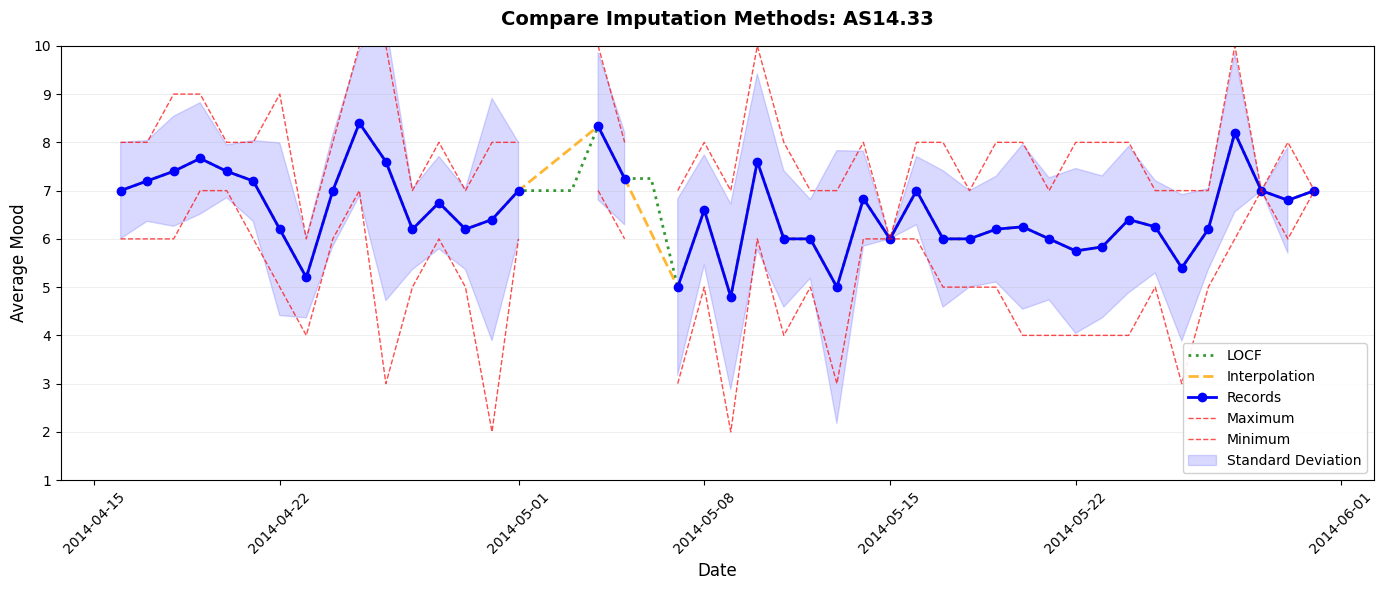

In [151]:
# Plots
# Plot 1: Time series of mood_mean + std users (before and after imputation)
user_sel = "AS14.33" # select users: see the difference btw "AS14.01" and "AS14.33"

df_orig = df_wide[df_wide["id"] == user_sel]
df_locf = df_LOCF[df_LOCF["id"] == user_sel]
df_interp = df_interpolation[df_interpolation["id"] == user_sel]


plt.figure(figsize=(14, 6))
plt.plot(df_locf["date"], df_locf["mood_mean"], 
         label="LOCF", color="green", linestyle=":", linewidth=2, alpha=0.8)

plt.plot(df_interp["date"], df_interp["mood_mean"], 
         label="Interpolation", color="orange", linestyle="--", linewidth=2, alpha=0.8)

plt.plot(df_orig["date"], df_orig["mood_mean"], 
         label="Records", color="blue", marker="o", markersize=6, linewidth=2)

plt.plot(df_orig["date"], df_orig["mood_max"], 
         label="Maximum", color="red", linestyle="--", linewidth=1, alpha=0.7)

plt.plot(df_orig["date"], df_orig["mood_min"], 
         label="Minimum", color="red", linestyle="--", linewidth=1, alpha=0.7)

plt.fill_between(df_orig["date"], 
                 df_orig["mood_mean"] - df_orig["mood_std"], 
                 df_orig["mood_mean"] + df_orig["mood_std"], 
                 color="blue", alpha=0.15, label="Standard Deviation")

plt.title(f"Compare Imputation Methods: {user_sel}", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Mood", fontsize=12)
plt.ylim(1, 10) 
plt.legend(loc="lower right", framealpha=0.9)
plt.grid(True, axis='y', alpha=0.3) 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

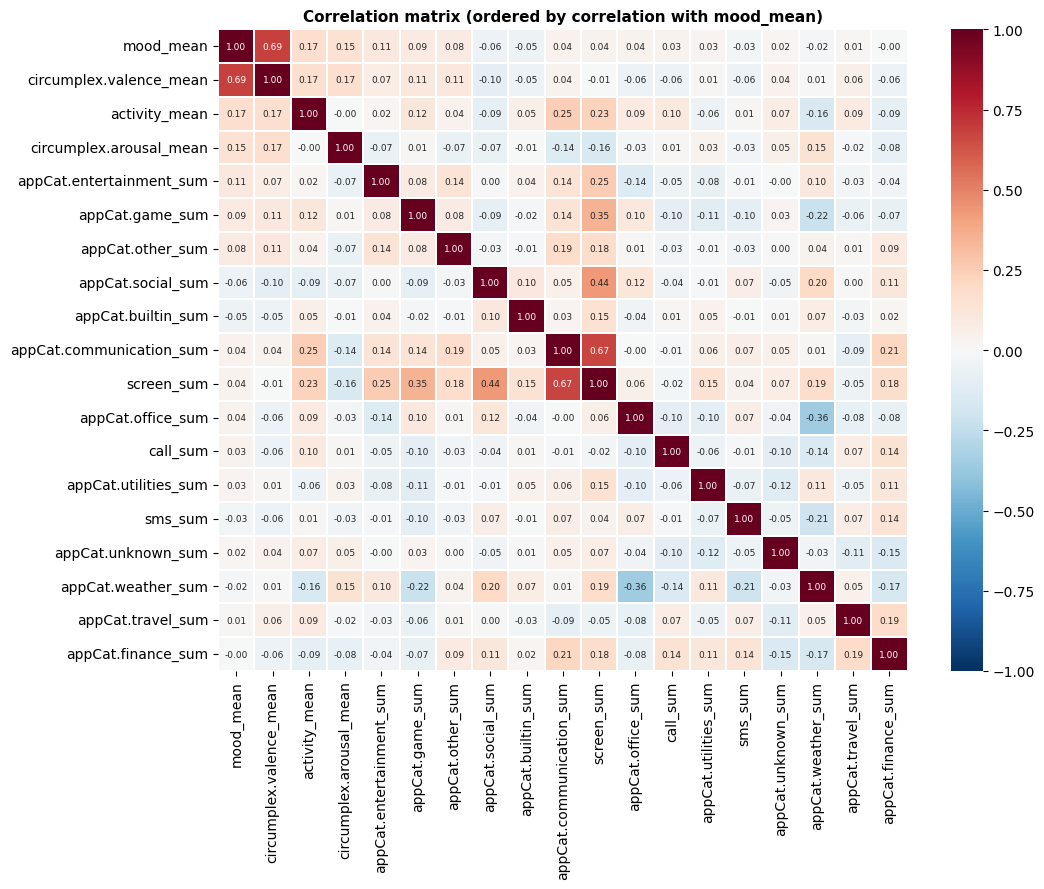

In [152]:
cols_to_correlate = ["mood_mean", "circumplex.arousal_mean", "circumplex.valence_mean", 'appCat.builtin_sum',
       'appCat.communication_sum', 'appCat.entertainment_sum',
       'appCat.finance_sum', 'appCat.game_sum', 'appCat.office_sum',
       'appCat.other_sum', 'appCat.social_sum', 'appCat.travel_sum',
       'appCat.unknown_sum', 'appCat.utilities_sum', 'appCat.weather_sum',
       'call_sum', 'screen_sum', 'sms_sum', "activity_mean"]
corr_matrix = df_wide[cols_to_correlate].corr()
# order all variables by their correlation with mood_mean
order = corr_matrix["mood_mean"].abs().sort_values(ascending=False).index
corr_matrix = corr_matrix.loc[order, order]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": 6.5},
    ax=ax,
)
ax.set_title("Correlation matrix (ordered by correlation with mood_mean)", fontweight="bold")
plt.tight_layout()
plt.show()

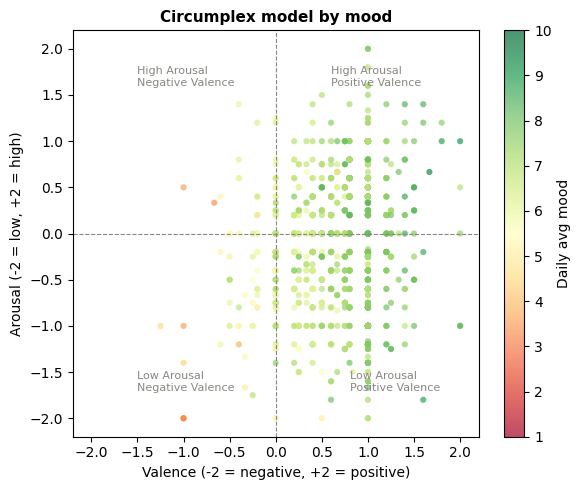

In [153]:
circ = df_wide[["circumplex.valence_mean", "circumplex.arousal_mean", "mood_mean"]].dropna()

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(circ["circumplex.valence_mean"], circ["circumplex.arousal_mean"],
                c=circ["mood_mean"], cmap="RdYlGn", vmin=1, vmax=10,
                alpha=0.7, linewidths=0, s=20)
plt.colorbar(sc, ax=ax, label="Daily avg mood")
plt.axhline(0, color=GRAY, lw=0.8, ls="--")
plt.axvline(0, color=GRAY, lw=0.8, ls="--")
plt.ylim(-2.2, 2.2)
plt.xlim(-2.2, 2.2)
plt.xlabel("Valence (-2 = negative, +2 = positive)")
plt.ylabel("Arousal (-2 = low, +2 = high)")
plt.title("Circumplex model by mood")
for x, y, lbl in [(.6, 1.6, "High Arousal\nPositive Valence"), (.8, -1.7, "Low Arousal\nPositive Valence"),
                   (-1.5, 1.6, "High Arousal\nNegative Valence"), (-1.5, -1.7, "Low Arousal\nNegative Valence")]:
    plt.text(x, y, lbl, fontsize=8, color=GRAY)
plt.tight_layout()
plt.show()

## Notes

### 1.A
- data is between 02/2014 until 06/2014, but only for 2 people feb and june are included
- appCat.builtin and entertainment have min negative values: remove or clip?
- usage times have extreme outliers (e.g. screen max is approx 2.7 hours, social is 8h and office is 9h)
- call and sms mark events
- mood mean = 7.0, std = 1.0
- circumplex.valence mean = 0.69 (positive), arousal mean = -0.10 (calm)


### 1.B Data Cleaning

- Imputation
(i) There are a lot of not available data points. In areas like valence, mood and arousal I will assume that these are genuinely missed days and that these points will have to be imputed. On the other hand, there are multiple NaNs in columns such as finance or weather apps. For now I will replace these NaNs with 0s, as my assumption is that people did not use these apps on certain days, and that their use would've been tracked automatically.

(ii) LOCF is a common method we used in our bachelor when dealing with clinical data, so I kind of chose it because I am a familiar with it (and it's super easy to implement). I think it also makes sense here, if a participant forgot to self report, then taking the value from their last known report would be fair, albeit a generalizaition of their mood.

Sources:

https://medium.com/@aaabulkhair/data-imputation-demystified-time-series-data-69bc9c798cb7 (not clear scientific journal)

https://www.lexjansen.com/nesug/nesug09/po/PO12.pdf

Preliminary Discussion:

A possible problem that comes with LOCF is that it may be introducing bias in cases where data is not stationary. Here I am assuming that yesterdays mood value can be assumed for today, and although I don't think it's an invalid assumption, I would say it introduces bias. Seems like not that many NaNs were imputed, but that's largely due to the first rows of the dataset being empty. The method cannot impute retroactivcely. And if we did decide to backfill those, that would be a lot of made up datapoints.

(iii) Mean imputation: Clearly this method did not impute as many data points as the previously used LOCF method. If I enlarge the time window, then more data points are imputed but I thought that 3 days was a reasonable amount (although I am struggling to find a source to support mt decision making here). From these results, I think the LOCF method makes more sense to me and is more effective here. It manages to impute more data points, and is based only off the emotion of the previous day not off of three days prior. Logically I think the argument for using it in this context is more sound than then rolling mean.**INTERPOLATION??**
 
- currently most cleaned version of data: df_wide_LOCF_cleaned **Based on imputation method we use...**

- could still remove extremities, I just focused on removing values that were actually impossible. But I wasn't sure how skeptical I could be with the values for certain app usages. **WINSORIZATION? Check also after modelling**

    - for example: the maximum time for using built in apps is almost 11 hours in a day. Logically I don't think someone is spending 11 hours in the calendar app. So I theorized doing a percentile cutoff of maybe the top 1% and bottom 1%. But he hasn't mentioned this in the lectures, and I feel I can't really justify it right now.

- data should be in correct format and ready for part 1C

- the assignment asks: "also consider what to do with prolonged periodsof missing data in a time series."
    - I just removed those initial 22 days of rows of NaNs, instead of imputing it. In my eyes, filling in that much data would be wrong. But that's more coming from my psychology background and I wonder whether he is expecting us to impute that data somehow, perhaps with a more advanced method? I'm not sure. Many decisions in this cleaning part that I think we can discuss together. **YES and done!**
 

09.04 review 

I merged 1A and 1B: 
- we remove only negative values (4 in total) for a couple of variables because we consider them as invalid since they would imply a negative screen time
- we remove pivot the dataset by performing aggregations using more stats than only the mean since it might be interesting (however these are not yet imputed). We need to check what types of variable "activity", "calls" and "sms" are and how to interpret them. Compared to Davids original code, I summed calls and sms since i think they can be interpreted as number of calls/sms throughout the day. 
- we see that some users have larger (>3? what do you think is large?) gaps in mood recordings, so we remove data before larger gaps 
- we perform imputation: 0 for recorded variables since it means user did not use the app. For mood related variables we use either forward fill or interpolation (if David agrees, it might be better than the mean. Even though we should discuss it more)
- for plots, i kept only three but feel free to suggest more interesting/relevant visualizations

- for feature engineering, basic aggregation is already done, maybe we can do some more rolling mean/standard dev,
 and check whether there are any interesting relationships between max, min, etc, ... (already in the dataset)
- maybe we could try to recode a combination of valence + arousal, e.g. one category if they are both positive, one if they are both negative, etc

- for modelling, would be nice to explore 2/3 models from the easiest to a neural network

## 1C - FEATURE ENGINEERING
#### Adding the target value - next day mood

In [154]:
# use either df_LOCF or df_interpolation for the rest of the analyses

In [155]:
'''df_interpolation = df_interpolation.sort_values(['id', 'date'])
df_interpolation['mood_next'] = (df_interpolation.groupby('id')['mood_mean'].shift(-1)) ## THIS IS NOT NEEDED SINCE WE DO IT LATER AS WELL, RIGHT?
df_interpolation.head() '''

"df_interpolation = df_interpolation.sort_values(['id', 'date'])\ndf_interpolation['mood_next'] = (df_interpolation.groupby('id')['mood_mean'].shift(-1)) ## THIS IS NOT NEEDED SINCE WE DO IT LATER AS WELL, RIGHT?\ndf_interpolation.head() "

In [156]:
'''#now the last day for each subject has a nan target - we drop it
print("Number of missing values in mood_next:", df_interpolation["mood_next"].isna().sum())
# drop:
df_interpolation = df_interpolation.dropna(subset=['mood_next'])'''

'#now the last day for each subject has a nan target - we drop it\nprint("Number of missing values in mood_next:", df_interpolation["mood_next"].isna().sum())\n# drop:\ndf_interpolation = df_interpolation.dropna(subset=[\'mood_next\'])'

In [157]:
#adding a weekday
df_interpolation["day_of_week"] = df_interpolation["date"].dt.day_name()
df_interpolation["weekend"] = df_interpolation["day_of_week"].isin(["Saturday", "Sunday"])
df_interpolation.columns

Index(['id', 'date', 'activity_mean', 'circumplex.arousal_mean',
       'circumplex.valence_mean', 'mood_mean', 'activity_max',
       'circumplex.arousal_max', 'circumplex.valence_max', 'mood_max',
       'activity_min', 'circumplex.arousal_min', 'circumplex.valence_min',
       'mood_min', 'activity_std', 'circumplex.arousal_std',
       'circumplex.valence_std', 'mood_std', 'activity_count',
       'circumplex.arousal_count', 'circumplex.valence_count', 'mood_count',
       'appCat.builtin_sum', 'appCat.communication_sum',
       'appCat.entertainment_sum', 'appCat.finance_sum', 'appCat.game_sum',
       'appCat.office_sum', 'appCat.other_sum', 'appCat.social_sum',
       'appCat.travel_sum', 'appCat.unknown_sum', 'appCat.utilities_sum',
       'appCat.weather_sum', 'call_sum', 'screen_sum', 'sms_sum',
       'day_of_week', 'month', 'weekend'],
      dtype='object')

In [158]:
df_feature = df_interpolation.copy() # copy of df that will be

df_feature = df_feature.rename(columns={'circumplex.arousal_mean': 'arousal_mean','circumplex.valence_mean': 'valence_mean'})
df_feature = df_feature.sort_values(['id', 'date']) #sorting df by id and date - will be used to make aggregates of the rolling window

df_feature['weekend'] = df_feature['weekend'].astype(int) # convert weekend column from true/false to 1/0
# weekday and month dummies
df_feature['date'] = pd.to_datetime(df_feature['date'])
df_feature['day_of_week'] = df_feature['date'].dt.day_name()
df_feature["month"] = df_feature["date"].dt.month_name()
day_dummies = pd.get_dummies(df_feature['day_of_week'], dtype=int)
month_dummies = pd.get_dummies(df_feature['month'], dtype=int)
df_feature = pd.concat([df_feature, day_dummies, month_dummies], axis=1)
# list of day names for the loop
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months = ["February", "March", "April", "May", "June"]
appcat_cols = [col for col in df_feature.columns if  col.endswith("_sum")]
            

mood_cols = ['mood_mean', 'arousal_mean', 'valence_mean',"activity_mean" ] 
window = 5 #the prediction is based on past 5 days - as in the example
instances = []


Next three cells come from litereature review:
- new feature... histogram for activity variables (ratio of toal amount spent online)
- autocorellation to check day window

In [159]:
# Normalize app-category usage within each participant-day
only_apps = [col for col in df_feature.columns if col.endswith("_sum") and "appCat" in col]

# Total app usage per participant per day (row-wise across app categories)
df_feature["total_app_time"] = df_feature[only_apps].sum(axis=1)

# Avoid division by zero
df_feature["total_app_time"] = df_feature["total_app_time"].replace(0, np.nan)

# Create normalized histogram (proportions)
for col in only_apps:
    new_col = col.replace("_sum", "_hist")
    df_feature[new_col] = df_feature[col] / df_feature["total_app_time"]

# Fill NaNs back to 0 (days with no app usage)
hist_cols = [col.replace("_sum", "_hist") for col in only_apps]
df_feature[hist_cols] = df_feature[hist_cols].fillna(0)
display(df_feature)

,id,date,activity_mean,arousal_mean,valence_mean,mood_mean,activity_max,circumplex.arousal_max,circumplex.valence_max,mood_max,...,appCat.entertainment_hist,appCat.finance_hist,appCat.game_hist,appCat.office_hist,appCat.other_hist,appCat.social_hist,appCat.travel_hist,appCat.unknown_hist,appCat.utilities_hist,appCat.weather_hist
0,AS14.01,2014-03-21,0.134050,0.200000,0.2,6.20,0.798387,1.0,1.0,7.0,...,0.059571,0.002930,0.0,0.010183,0.014177,0.266590,0.054131,0.000000,0.035405,0.000000
1,AS14.01,2014-03-22,0.236880,0.600000,0.5,6.40,0.508475,1.0,1.0,7.0,...,0.014354,0.003242,0.0,0.000000,0.015096,0.067621,0.005738,0.000000,0.018092,0.000000
2,AS14.01,2014-03-23,0.142741,0.200000,0.8,6.80,0.313559,1.0,1.0,8.0,...,0.012260,0.005640,0.0,0.000000,0.009463,0.117061,0.000000,0.000000,0.003910,0.003949
3,AS14.01,2014-03-24,0.078961,0.800000,0.0,6.00,0.361345,2.0,1.0,7.0,...,0.064956,0.002268,0.0,0.000200,0.004425,0.214331,0.027912,0.000000,0.011883,0.000000
4,AS14.01,2014-03-25,0.098374,0.500000,0.5,6.75,0.594828,1.0,1.0,8.0,...,0.004880,0.003080,0.0,0.000000,0.012794,0.137329,0.000000,0.016829,0.015947,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2049,AS14.33,2014-05-27,0.012704,-0.600000,0.4,6.20,0.109244,1.0,1.0,7.0,...,0.024266,0.000000,0.0,0.000000,0.027767,0.391220,0.000000,0.000000,0.010931,0.000000
2050,AS14.33,2014-05-28,0.103301,0.000000,1.2,8.20,0.412281,2.0,2.0,10.0,...,0.054007,0.000000,0.0,0.031445,0.046560,0.471030,0.000000,0.000000,0.002694,0.000000
2051,AS14.33,2014-05-29,0.169354,-1.333333,1.0,7.00,0.625000,-1.0,1.0,7.0,...,0.048920,0.000000,0.0,0.000000,0.010447,0.640370,0.000336,0.000000,0.001144,0.000000
2052,AS14.33,2014-05-30,0.192901,-0.800000,-0.4,6.80,0.731092,1.0,1.0,8.0,...,0.027427,0.000000,0.0,0.000000,0.005545,0.333740,0.110949,0.000851,0.024540,0.000000


In [160]:
'''
df_feature = df_feature.sort_values(['id', 'date'])

for col in only_apps:
    df_feature[col + '_3d'] = (
        df_feature.groupby('id')[col]
        .rolling(window=3, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
    )

# normalize again
total_3d = df_feature[[col + '_3d' for col in only_apps]].sum(axis=1)
total_3d = total_3d.replace(0, np.nan)

for col in only_apps:
    new_col = col.replace('_sum', '_hist_3d')
    df_feature[new_col] = df_feature[col + '_3d'] / total_3d

# fill NaNs
hist_3d_cols = [col.replace('_sum', '_hist_3d') for col in only_apps]
df_feature[hist_3d_cols] = df_feature[hist_3d_cols].fillna(0)'''

"\ndf_feature = df_feature.sort_values(['id', 'date'])\n\nfor col in only_apps:\n    df_feature[col + '_3d'] = (\n        df_feature.groupby('id')[col]\n        .rolling(window=3, min_periods=1)\n        .sum()\n        .reset_index(level=0, drop=True)\n    )\n\n# normalize again\ntotal_3d = df_feature[[col + '_3d' for col in only_apps]].sum(axis=1)\ntotal_3d = total_3d.replace(0, np.nan)\n\nfor col in only_apps:\n    new_col = col.replace('_sum', '_hist_3d')\n    df_feature[new_col] = df_feature[col + '_3d'] / total_3d\n\n# fill NaNs\nhist_3d_cols = [col.replace('_sum', '_hist_3d') for col in only_apps]\ndf_feature[hist_3d_cols] = df_feature[hist_3d_cols].fillna(0)"

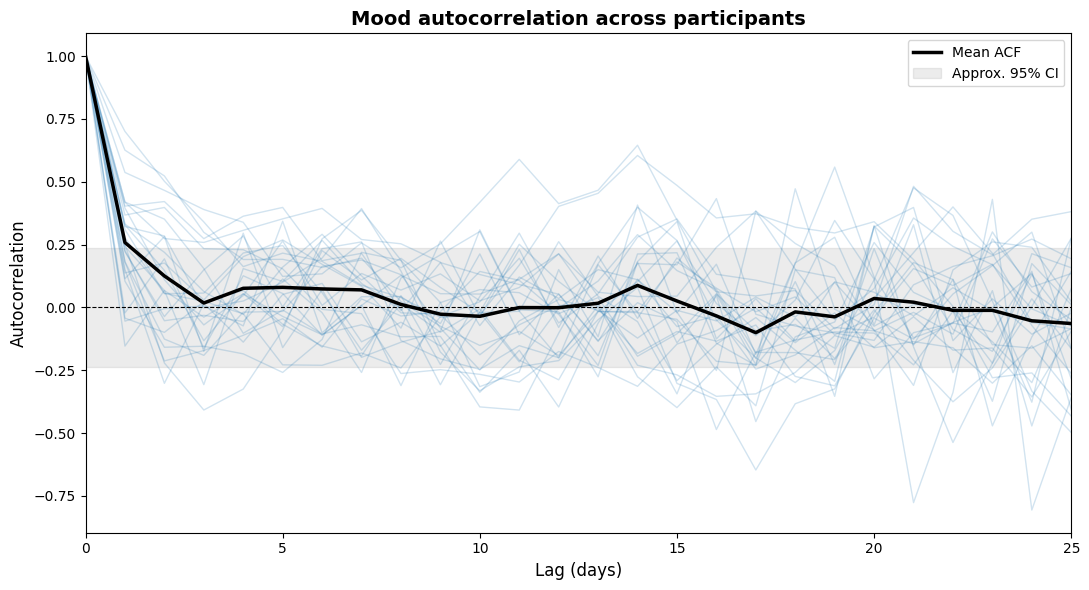

Included participants: 27
Participant IDs: ['AS14.01', 'AS14.02', 'AS14.03', 'AS14.05', 'AS14.06', 'AS14.07', 'AS14.08', 'AS14.09', 'AS14.12', 'AS14.13', 'AS14.14', 'AS14.15', 'AS14.16', 'AS14.17', 'AS14.19', 'AS14.20', 'AS14.23', 'AS14.24', 'AS14.25', 'AS14.26', 'AS14.27', 'AS14.28', 'AS14.29', 'AS14.30', 'AS14.31', 'AS14.32', 'AS14.33']


In [161]:
# ACF across all participants without statsmodels
max_lag = 25
acf_rows = []
included_ids = []

for pid, g in df_interpolation.groupby("id"):
    s = (
        g.sort_values("date")["mood_mean"]
        .dropna()
        .reset_index(drop=True)
    )
    if len(s) <= max_lag:
        continue

    ac_vals = [1.0] + [s.autocorr(lag=k) for k in range(1, max_lag + 1)]
    acf_rows.append(ac_vals)
    included_ids.append(pid)

if not acf_rows:
    raise ValueError("No participant has enough observations for the chosen max_lag.")

acf_mat = np.asarray(acf_rows, dtype=float)
mean_acf = np.nanmean(acf_mat, axis=0)
lags = np.arange(max_lag + 1)

fig, ax = plt.subplots(figsize=(11, 6))

# Thin lines for each participant
for row in acf_mat:
    ax.plot(lags, row, color="C0", alpha=0.20, linewidth=1)

# Bold line for average autocorrelation
ax.plot(lags, mean_acf, color="black", linewidth=2.5, label="Mean ACF")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Approximate 95% CI band for visual reference
max_n = max(
    len(
        df_interpolation.loc[df_interpolation["id"] == pid, "mood_mean"].dropna()
    )
    for pid in included_ids
)
ci = 1.96 / np.sqrt(max_n)
ax.fill_between(lags, -ci, ci, color="gray", alpha=0.15, label="Approx. 95% CI")

ax.set_title("Mood autocorrelation across participants", fontsize=14, fontweight="bold")
ax.set_xlabel("Lag (days)", fontsize=12)
ax.set_ylabel("Autocorrelation", fontsize=12)
ax.set_xlim(0, max_lag)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Included participants: {len(included_ids)}")
print("Participant IDs:", included_ids)

In [162]:
for patient_id, group in df_feature.groupby('id'): #separate df for each patient to prevent data leak - this also handles patients having different starting dates
    group = group.reset_index(drop=True) #reset index 
    for t in range(window, len(group)): #starting at day 6
        window_days = group.iloc[t - window:t] # 5 days before day t
        t_day = group.iloc[t] # prediction day
        
        row = {'id': patient_id, 'date': t_day['date']}
        
        for col in mood_cols: #summary stats over the 5 days - autmatically calucaltes the stats for all predictor columns
            name = col.replace('_mean', '') 
            row[f'{name}_mean_{window}d'] = window_days[col].mean()   # average mood/arousal/valence over window
            row[f'{name}_std_{window}d']  = window_days[col].std()    # standard deviation
            row[f'{name}_min_{window}d']  = window_days[col].min()    # lowest value in the window
            row[f'{name}_max_{window}d']  = window_days[col].max()    # max value in the window
            if col != "activity_mean":
                row[f'{name}_slope_{window}d'] = np.polyfit(range(window), window_days[col].values, 1)[0] # slope of the predictor over the window —  if positive it's improving
                row[f'{name}_ema_{window}d'] = window_days[col].ewm(span=window, adjust=False).mean().iloc[-1] # exponential moving average - more weight to recent days
        
        for col in appcat_cols: #only avg and sum
            name = col.replace('appCat.', 'appCat_').replace('_sum', '')
            row[f'{name}_mean_{window}d'] = window_days[col].mean() # average daily app category usage over window
            row[f'{name}_sum_{window}d']  = window_days[col].sum()  # total app category usage over window

        #day of the week dummies for the current day
        for d in days:
            row[d] = t_day[d]
        
        for m in months:
            row[m] = int(t_day[m]) if m in t_day.index else 0
        
        row['weekend'] = t_day['weekend'] 

        row['target_mood'] = t_day['mood_mean'] #target mood value
        instances.append(row) # add the prediction row to list

df_ml = pd.DataFrame(instances) #new df for ML prediction
display(df_ml.shape)
display(df_ml.head())

(1154, 68)

,id,date,mood_mean_5d,mood_std_5d,mood_min_5d,mood_max_5d,mood_slope_5d,mood_ema_5d,arousal_mean_5d,arousal_std_5d,...,Friday,Saturday,Sunday,February,March,April,May,June,weekend,target_mood
0,AS14.01,2014-03-26,6.43,0.345688,6.0,6.8,0.070,6.447531,0.46,0.260768,...,0,0,0,0,1,0,0,0,0,6.6
1,AS14.01,2014-03-27,6.51,0.324808,6.0,6.8,0.035,6.524691,0.38,0.389872,...,0,0,0,0,1,0,0,0,0,7.0
2,AS14.01,2014-03-28,6.63,0.380132,6.0,7.0,0.100,6.735802,0.30,0.374166,...,1,0,0,0,1,0,0,0,0,6.4
3,AS14.01,2014-03-29,6.55,0.377492,6.0,7.0,0.105,6.518519,0.14,0.554977,...,0,1,0,0,1,0,0,0,1,8.0
4,AS14.01,2014-03-30,6.95,0.626498,6.4,8.0,0.230,7.111111,0.02,0.426615,...,0,0,1,0,1,0,0,0,1,7.5


**Addedd exponential moving average and month dummies: can be interpreted as weather/seasonality??** Also sms and calls as sociality.

In [163]:
interesting_cols = [col for col in df_ml.columns if any(x in col for x in ['mood', 'arousal', 'valence', 'appCat', 'activity'])]
df_ml[interesting_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mood_mean_5d,1154.0,6.989240,0.531606,4.546667,6.754167,7.021667e+00,7.300000,8.400000
mood_std_5d,1154.0,0.495353,0.269347,0.000000,0.318983,4.604346e-01,0.609918,1.804370
mood_min_5d,1154.0,6.365538,0.782846,3.000000,6.000000,6.400000e+00,7.000000,7.833333
mood_max_5d,1154.0,7.587738,0.542396,5.500000,7.200000,7.600000e+00,8.000000,9.333333
mood_slope_5d,1154.0,0.001824,0.208080,-0.975000,-0.120000,3.243169e-16,0.120000,0.666667
mood_ema_5d,1154.0,6.990403,0.539688,4.639506,6.752160,7.013580e+00,7.320370,8.565432
arousal_mean_5d,1154.0,-0.103969,0.460301,-1.386667,-0.390000,-1.100000e-01,0.207500,1.160000
arousal_std_5d,1154.0,0.475485,0.218049,0.022361,0.323650,4.381780e-01,0.587686,1.375500
arousal_min_5d,1154.0,-0.688410,0.555507,-2.000000,-1.000000,-7.500000e-01,-0.250000,0.800000
arousal_max_5d,1154.0,0.478141,0.511756,-1.000000,0.200000,5.000000e-01,0.800000,2.000000


In [164]:
time_cols = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday',
       'Saturday', 'Sunday', 'February', 'March', 'April', 'May', 'June',
       'weekend']
df_ml[time_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Monday,1154.0,0.144714,0.351965,0.0,0.0,0.0,0.0,1.0
Tuesday,1154.0,0.139515,0.346633,0.0,0.0,0.0,0.0,1.0
Wednesday,1154.0,0.145581,0.352838,0.0,0.0,0.0,0.0,1.0
Thursday,1154.0,0.145581,0.352838,0.0,0.0,0.0,0.0,1.0
Friday,1154.0,0.141248,0.348428,0.0,0.0,0.0,0.0,1.0
Saturday,1154.0,0.142114,0.349319,0.0,0.0,0.0,0.0,1.0
Sunday,1154.0,0.141248,0.348428,0.0,0.0,0.0,0.0,1.0
February,1154.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
March,1154.0,0.136915,0.343907,0.0,0.0,0.0,0.0,1.0
April,1154.0,0.629983,0.483018,0.0,0.0,1.0,1.0,1.0


# 2A. - CLASSIFICATION
predicting a fixed number of classes with the mood of the next day

### determining classes

count    1154.000000
mean        6.994642
std         0.740813
min         3.000000
25%         6.600000
50%         7.000000
75%         7.500000
max         9.333333
Name: target_mood, dtype: float64


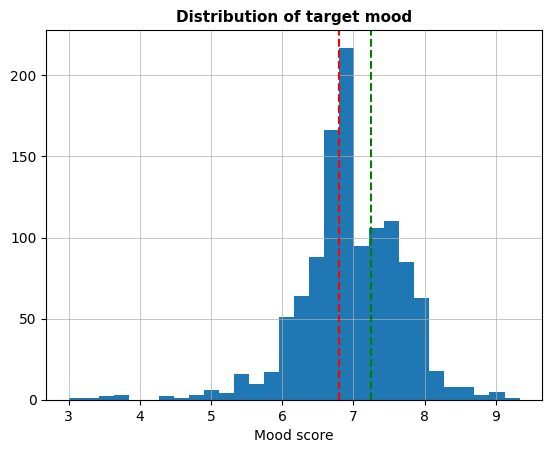

In [165]:
print(df_ml['target_mood'].describe())

df_ml['target_mood'].hist(bins=30)
plt.axvline(df_ml['target_mood'].quantile(0.33), color='r', linestyle='--', label='33rd percentile')
plt.axvline(df_ml['target_mood'].quantile(0.66), color='g', linestyle='--', label='66th percentile')
plt.xlabel('Mood score')
plt.title('Distribution of target mood')
plt.show()


we see that mood is right-skewed and tighgtly compressed around 7, we analyse the data further to create balanced classses.

**Do we want to prioritize balancing or interpretation?** e.g. mood less than 6,6-8, >8 ... and then control for imbalanced classes with XGboost

In [166]:
# resulting class balance
q33 = df_ml['target_mood'].quantile(0.33)
q66 = df_ml['target_mood'].quantile(0.66)

print(f"33rd percentile cutoff: {q33:.2f}")
print(f"66th percentile cutoff: {q66:.2f}")
df_ml['mood_class'] = pd.cut(
    df_ml['target_mood'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]
)

# label names
class_names = {0: 'bad mood', 1: 'good mood', 2: 'very good mood'}


df_ml['mood_class'] = df_ml['mood_class'].astype(int) # for sk learn
print(df_ml['mood_class'].value_counts().sort_index())
print(f"Percentages: {df_ml['mood_class'].value_counts(normalize=True).round(2).sort_index()}")

33rd percentile cutoff: 6.80
66th percentile cutoff: 7.25
mood_class
0    435
1    349
2    370
Name: count, dtype: int64
Percentages: mood_class
0    0.38
1    0.30
2    0.32
Name: proportion, dtype: float64


Alternatively we can priositise interpretability: a bad day now  means a low score no matter how many people felt that way.

we now need F1-Weighted or Macro-F1 for XGBoost


In [168]:
low_threshold = 6.0
high_threshold = 7.5

# categorize based on absolute values
df_ml['mood_class'] = pd.cut(
    df_ml['target_mood'],
    bins=[-np.inf, low_threshold, high_threshold, np.inf],
    labels=[0, 1, 2],
    include_lowest=True
)

# map labels for clarity
class_names = {0: 'Low/Bad (<6)', 1: 'Neutral/Good (6-7.5)', 2: 'High/Excellent (>7.5)'}

df_ml['mood_class'] = df_ml['mood_class'].astype(int)

# check the distribution
counts = df_ml['mood_class'].value_counts().sort_index()
pcts = df_ml['mood_class'].value_counts(normalize=True).sort_index()

for i, name in class_names.items():
    print(f"Class {i} ({name}): {counts[i]} samples ({pcts[i]:.2%})")

display(df_ml)
df_ml_reg = df_ml.copy()

Class 0 (Low/Bad (<6)): 116 samples (10.05%)
Class 1 (Neutral/Good (6-7.5)): 785 samples (68.02%)
Class 2 (High/Excellent (>7.5)): 253 samples (21.92%)


,id,date,mood_mean_5d,mood_std_5d,mood_min_5d,mood_max_5d,mood_slope_5d,mood_ema_5d,arousal_mean_5d,arousal_std_5d,...,Saturday,Sunday,February,March,April,May,June,weekend,target_mood,mood_class
0,AS14.01,2014-03-26,6.430000,0.345688,6.0,6.8,0.070000,6.447531,0.460000,0.260768,...,0,0,0,1,0,0,0,0,6.6,1
1,AS14.01,2014-03-27,6.510000,0.324808,6.0,6.8,0.035000,6.524691,0.380000,0.389872,...,0,0,0,1,0,0,0,0,7.0,1
2,AS14.01,2014-03-28,6.630000,0.380132,6.0,7.0,0.100000,6.735802,0.300000,0.374166,...,0,0,0,1,0,0,0,0,6.4,1
3,AS14.01,2014-03-29,6.550000,0.377492,6.0,7.0,0.105000,6.518519,0.140000,0.554977,...,1,0,0,1,0,0,0,1,8.0,2
4,AS14.01,2014-03-30,6.950000,0.626498,6.4,8.0,0.230000,7.111111,0.020000,0.426615,...,0,1,0,1,0,0,0,1,7.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1149,AS14.33,2014-05-27,5.926667,0.401836,5.4,6.4,-0.028333,5.848971,-0.446667,0.554952,...,0,0,0,0,0,1,0,0,6.2,1
1150,AS14.33,2014-05-28,6.016667,0.402768,5.4,6.4,-0.026667,5.976955,-0.666667,0.171189,...,0,0,0,0,0,1,0,0,8.2,2
1151,AS14.33,2014-05-29,6.490000,1.032231,5.4,8.2,0.355000,6.792593,-0.500000,0.314245,...,0,0,0,0,0,1,0,0,7.0,1
1152,AS14.33,2014-05-30,6.610000,1.053803,5.4,8.2,0.430000,6.841975,-0.616667,0.489614,...,0,0,0,0,0,1,0,0,6.8,1


## a) XGBoost
- as we have 3 classes, not 2 we use the data from task 1C

In [ ]:
# feature and target matrix
X = df_ml.drop(columns=['id', 'date', 'target_mood', 'mood_class'])
y = df_ml['mood_class']

class_names = ['bad mood', 'good mood', 'very good mood']

# 1. train / test split
# first 80% of each patient's days go to train, the last 20% go to test set - always train on the past and test on the future
train_idx, test_idx = [], []

#getting indexes for the split
for patient_id, group in df_ml.groupby('id'):
    group= group.sort_values('date')
    n = len(group)
    split = int(n * 0.8)
    train_idx.extend(group.index[:split].tolist()) 
    test_idx.extend(group.index[split:].tolist())

X_train_full = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train_full = y.loc[train_idx]
y_test = y.loc[test_idx]

class_names = ['bad mood', 'good mood', 'very good mood']


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
# 2. baseline model -  we only use default xgboost parameters 
scaler_base = StandardScaler()
X_train_scaled = scaler_base.fit_transform(X_train_full)
X_test_scaled = scaler_base.transform(X_test)

baseline_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=1
)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_full)

baseline_model.fit(X_train_scaled, y_train_full, sample_weight=sample_weights)
y_baseline_pred = baseline_model.predict(X_train_scaled)  # on train — just to see starting point

print("── Baseline model (default parameters, evaluated on train) ──")
print(classification_report(y_train_full, y_baseline_pred, target_names=class_names))


── Baseline model (default parameters, evaluated on train) ──
                precision    recall  f1-score   support

      bad mood       1.00      1.00      1.00        84
     good mood       1.00      1.00      1.00       619
very good mood       1.00      1.00      1.00       189

      accuracy                           1.00       892
     macro avg       1.00      1.00      1.00       892
  weighted avg       1.00      1.00      1.00       892



In [ ]:
#3. randomised parameter search
# we refit the scaler on each training fold in the search - no validation statistics leak
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

# define what we want to optimize
param_grid = {
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__n_estimators': [100, 200, 300, 500],
    'model__subsample': [0.8, 1.0] # against overfitting - randomly sample 80% of the data for each tree
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        random_state=1
    ))
])

def group_time_series_split(groups, n_splits=5):
    folds_train = [[] for _ in range(n_splits)]
    folds_val = [[] for _ in range(n_splits)]

    for pid in np.unique(groups):
        # unique indexes for patient
        p_indices = np.where(groups == pid)[0]
        
        # split is done per patient
        for fold_idx, (tr, val) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(p_indices)):
            folds_train[fold_idx].extend(p_indices[tr])
            folds_val[fold_idx].extend(p_indices[val])
            
    # return list of train and val indexes for each fold
    for fold_idx in range(n_splits):        
        yield np.array(folds_train[fold_idx]), np.array(folds_val[fold_idx])



In [ ]:
groups_train = df_ml.loc[train_idx, 'id'].values
custom_cv = list(group_time_series_split(groups_train, n_splits=5))

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=50,# number of random combinations to try
    cv=custom_cv, # 5-fold time-series cross-validation inside search
    scoring='f1_weighted', # weighted F1 accounts for class imbalance
    random_state=1,
    n_jobs=-1,# all available CPU cores
    verbose=1
)

random_search.fit(X_train_full, y_train_full, model__sample_weight=sample_weights)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV F1 (weighted): {random_search.best_score_:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

In [ ]:
#checking the split #DELETE LATER
def verify_custom_cv(custom_cv, groups):
    print(f"Checking {len(custom_cv)} folds...\n")
    
    for i, (train_idx, val_idx) in enumerate(custom_cv):
        # 1. Check for index overlap (Leakage)
        overlap = set(train_idx).intersection(set(val_idx))
        
        # 2. Check temporal logic per user
        temporal_errors = 0
        for pid in np.unique(groups):
            # Indices for this specific patient in this fold
            p_train = train_idx[np.isin(train_idx, np.where(groups == pid)[0])]
            p_val = val_idx[np.isin(val_idx, np.where(groups == pid)[0])]
            
            if len(p_train) > 0 and len(p_val) > 0:
                if p_train.max() > p_val.min():
                    temporal_errors += 1
        
        print(f"Fold {i+1}:")
        print(f"  - Train size: {len(train_idx)}, Val size: {len(val_idx)}")
        print(f"  - Overlap check: {'FAIL' if overlap else 'PASS'}")
        print(f"  - Temporal check: {'FAIL' if temporal_errors > 0 else 'PASS'} ({temporal_errors} users leaked)")
        print("-" * 30)

# Execute
verify_custom_cv(custom_cv, groups_train)

Checking 5 folds...

Fold 1:
  - Train size: 202, Val size: 138
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------
Fold 2:
  - Train size: 340, Val size: 138
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------
Fold 3:
  - Train size: 478, Val size: 138
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------
Fold 4:
  - Train size: 616, Val size: 138
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------
Fold 5:
  - Train size: 754, Val size: 138
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------


Fold 1 — F1: 0.627 Accuracy: 0.630
Fold 2 — F1: 0.469 Accuracy: 0.471
Fold 3 — F1: 0.562 Accuracy: 0.565
Fold 4 — F1: 0.486 Accuracy: 0.500
Fold 5 — F1: 0.557 Accuracy: 0.572

Mean F1:0.540 ± 0.057
Mean Accuracy: 0.548 ± 0.056


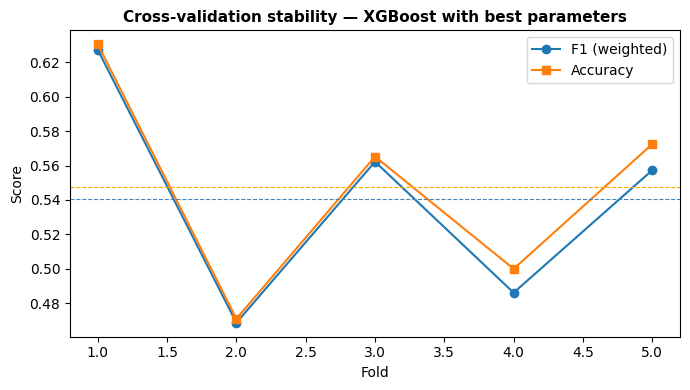

In [ ]:
# 4. 5-fold cross-validation with best parameters
# shows stability in each fold - checks if the performance is the same on all time periods
best_params = {k.replace('model__', ''): v for k, v in random_search.best_params_.items()}

fold_scores = {'f1': [], 'accuracy': []}

for fold, (tr_idx, val_idx) in enumerate(custom_cv):
    X_tr  = X_train_full.iloc[tr_idx]
    X_val = X_train_full.iloc[val_idx]
    y_tr  = y_train_full.iloc[tr_idx]
    y_val = y_train_full.iloc[val_idx]

    # scaler - separate inside each fold so validation statistics never leak into training
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    fold_model = xgb.XGBClassifier(
        **best_params,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        random_state=1
    )
    fold_model.fit(X_tr_scaled, y_tr, sample_weight=sample_weights)
    y_val_pred = fold_model.predict(X_val_scaled)

     # weighted f1 to account for slight class imbalance (better than raw accuracy)
    fold_f1 = f1_score(y_val, y_val_pred, average='weighted')
    fold_acc = (y_val == y_val_pred).mean()
    fold_scores['f1'].append(fold_f1)
    fold_scores['accuracy'].append(fold_acc)
    print(f"Fold {fold+1} — F1: {fold_f1:.3f} Accuracy: {fold_acc:.3f}")

print(f"\nMean F1:{np.mean(fold_scores['f1']):.3f} ± {np.std(fold_scores['f1']):.3f}")
print(f"Mean Accuracy: {np.mean(fold_scores['accuracy']):.3f} ± {np.std(fold_scores['accuracy']):.3f}")

# cross-validation fold scores plot (stability)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 6), fold_scores['f1'], marker='o', label='F1 (weighted)')
ax.plot(range(1, 6), fold_scores['accuracy'], marker='s', label='Accuracy')
ax.axhline(np.mean(fold_scores['f1']), linestyle='--', color='steelblue', linewidth=0.8)
ax.axhline(np.mean(fold_scores['accuracy']), linestyle='--', color='orange', linewidth=0.8)
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Cross-validation stability — XGBoost with best parameters')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 5. retrain final model on full training set
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_full)
X_test_scaled = scaler_final.transform(X_test)

final_model = xgb.XGBClassifier(
    **best_params,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=1
)
final_model.fit(X_train_scaled, y_train_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr


── Final test set performance ──
                precision    recall  f1-score   support

      bad mood       0.55      0.73      0.63        83
     good mood       0.47      0.26      0.34        72
very good mood       0.63      0.66      0.65        80

      accuracy                           0.57       235
     macro avg       0.55      0.55      0.54       235
  weighted avg       0.55      0.57      0.55       235



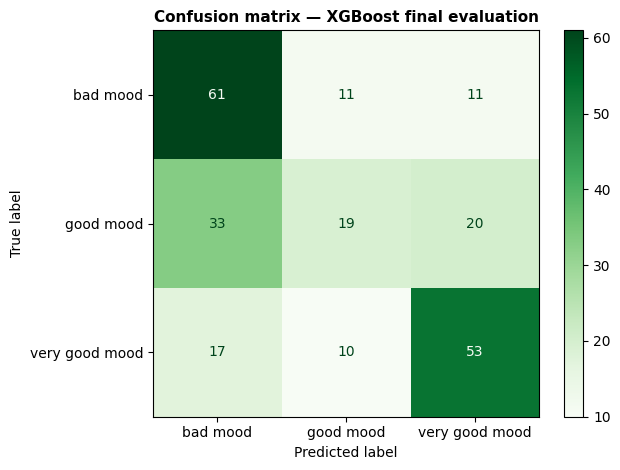

In [ ]:
# 6. final evaluation on test set
y_pred = final_model.predict(X_test_scaled)

print("\n── Final test set performance ──")
print(classification_report(y_test, y_pred, target_names=class_names))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Greens')
plt.title('Confusion matrix — XGBoost final evaluation')
plt.tight_layout()
plt.show()


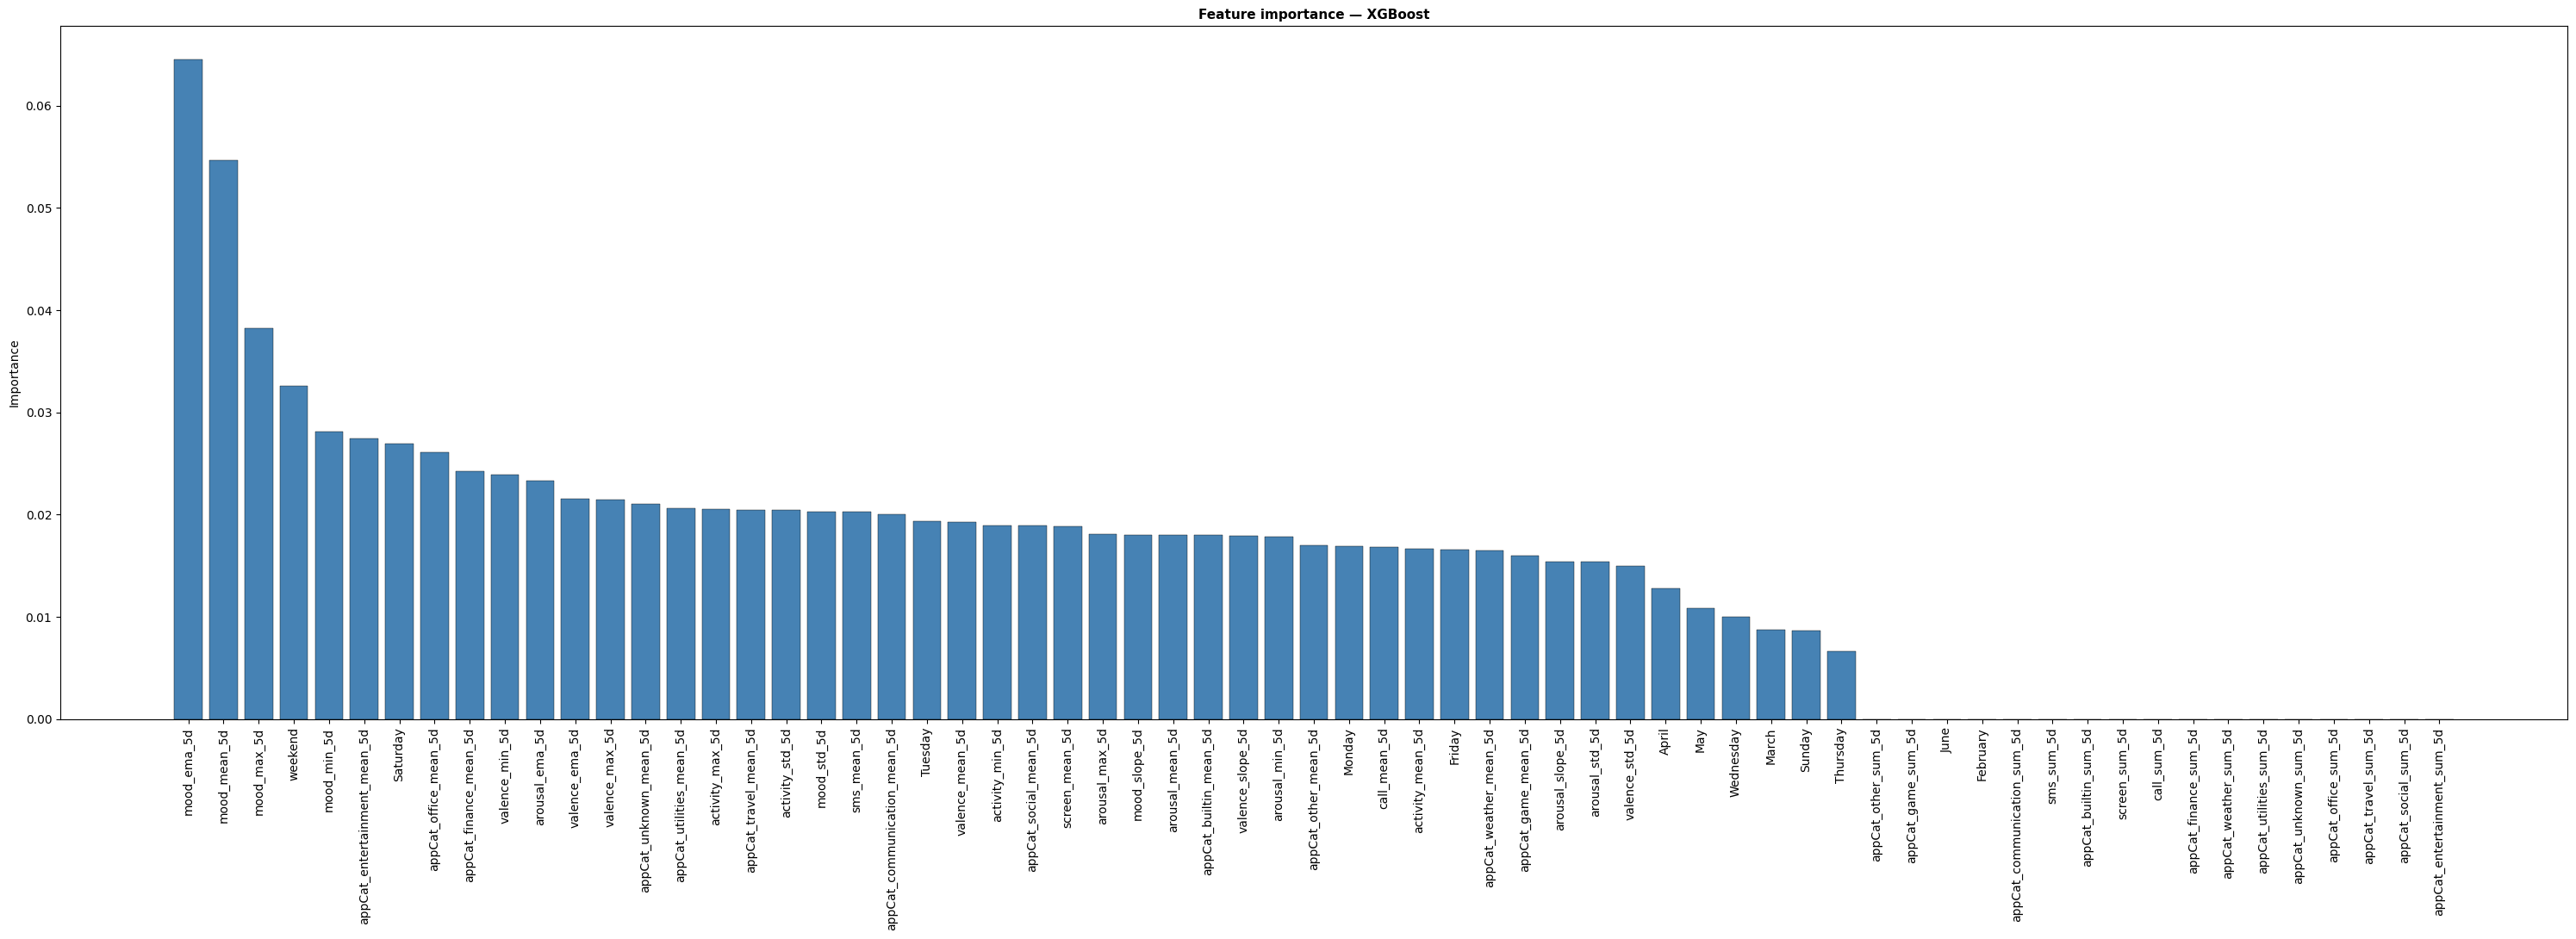

In [ ]:
importance_df = pd.DataFrame({'feature':X.columns,'importance': final_model.feature_importances_}).sort_values('importance', ascending=False)
fig, ax = plt.subplots(figsize=(30, 11)) # dynamic figure scaling
ax.bar(importance_df['feature'], importance_df['importance'], color='steelblue', edgecolor='k', linewidth=0.3)
ax.set_ylabel('Importance')
ax.set_title('Feature importance — XGBoost')
ax.tick_params(axis='x', rotation=90, labelsize=10)
plt.tight_layout()
plt.show()

### b) Recurrent neural network
(inherently temporal)
* good evaluation set up

In [ ]:
df_feature.columns

Index(['id', 'date', 'activity_mean', 'arousal_mean', 'valence_mean',
       'mood_mean', 'activity_max', 'circumplex.arousal_max',
       'circumplex.valence_max', 'mood_max', 'activity_min',
       'circumplex.arousal_min', 'circumplex.valence_min', 'mood_min',
       'activity_std', 'circumplex.arousal_std', 'circumplex.valence_std',
       'mood_std', 'activity_count', 'circumplex.arousal_count',
       'circumplex.valence_count', 'mood_count', 'appCat.builtin_sum',
       'appCat.communication_sum', 'appCat.entertainment_sum',
       'appCat.finance_sum', 'appCat.game_sum', 'appCat.office_sum',
       'appCat.other_sum', 'appCat.social_sum', 'appCat.travel_sum',
       'appCat.unknown_sum', 'appCat.utilities_sum', 'appCat.weather_sum',
       'call_sum', 'screen_sum', 'sms_sum', 'day_of_week', 'month', 'weekend',
       'Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday',
       'Wednesday', 'April', 'June', 'March', 'May', 'total_app_time',
       'appCat.builtin_hist

In [ ]:
lstm_window = 7 # more data needed for LSTM, we use 7 days (instead of 5 - see lit)
 
# Raw daily feature columns fed to the LSTM at each timestep
seq_cols = [
    col for col in df_feature.columns
    if any(s in col for s in ['mean', 'std', 'weekend', "total_app_time"])]

seq_cols += [d for d in days   if d in df_feature.columns]
seq_cols += [m for m in months if m in df_feature.columns]
seq_cols += [col for col in df_feature.columns if col.endswith('_hist') or col.endswith('_sum')]
 
# create dataframe for LSTM - each row is a sequence of 7 days of features predicting the mood of the next day
X_seq, y_seq_raw, groups_seq, dates_seq = [], [], [], []

for patient_id, group in df_feature.groupby('id'):
    group = group.sort_values('date').reset_index(drop=True)
    vals  = group[seq_cols].fillna(0).values          # (n_days, n_feats)
 
    for t in range(lstm_window, len(group)):
        X_seq.append(vals[t - lstm_window:t])         # (lstm_window, n_feats)
        y_seq_raw.append(group['mood_mean'].iloc[t])
        groups_seq.append(patient_id)
        dates_seq.append(group['date'].iloc[t])
 
X_seq      = np.array(X_seq)           # (n_samples, lstm_window, n_feats)
y_seq_raw  = np.array(y_seq_raw)
groups_seq = np.array(groups_seq)
print("Sequence data shape:", X_seq.shape)
 

Sequence data shape: (1100, 7, 48)


In [ ]:
# Map continuous mood to the same three classes as XGBoost
y_seq_class = pd.cut(
    y_seq_raw, bins=[-np.inf, q33, q66, np.inf], labels=[0, 1, 2]
).astype(int)

In [ ]:
val_ratio = 0.15 # per-patient validation ratio (15% of train goes to val, 85% stays in train)
 
X_tr_list,  y_tr_list  = [], []
X_val_list, y_val_list = [], []
X_te_list,  y_te_list  = [], []
 
for pid in np.unique(groups_seq):
    idx = np.where(groups_seq == pid)[0]
    n   = len(idx)
    te_split  = int(n * 0.80)                        # last 20 % = test
    val_split = int(te_split * (1 - val_ratio))      # last 15 % of train = val
 
    X_tr_list.extend(X_seq[idx[:val_split]])
    y_tr_list.extend(y_seq_class[idx[:val_split]])
 
    X_val_list.extend(X_seq[idx[val_split:te_split]])
    y_val_list.extend(y_seq_class[idx[val_split:te_split]])
 
    X_te_list.extend(X_seq[idx[te_split:]])
    y_te_list.extend(y_seq_class[idx[te_split:]])
 
X_tr_arr  = np.array(X_tr_list)
X_val_arr = np.array(X_val_list)
X_te_arr  = np.array(X_te_list)
y_tr_arr  = np.array(y_tr_list)
y_val_arr = np.array(y_val_list)
y_te_arr  = np.array(y_te_list)
 
n_steps, n_feats = X_tr_arr.shape[1], X_tr_arr.shape[2]
 
# scaler: fit on training set only
scaler_rnn = StandardScaler()
X_tr_sc  = scaler_rnn.fit_transform(X_tr_arr.reshape(-1, n_feats)).reshape(-1, n_steps, n_feats)
X_val_sc = scaler_rnn.transform(X_val_arr.reshape(-1, n_feats)).reshape(-1, n_steps, n_feats)
X_te_sc  = scaler_rnn.transform(X_te_arr.reshape(-1, n_feats)).reshape(-1, n_steps, n_feats)
 
y_tr_cat  = to_categorical(y_tr_arr,  num_classes=3)
y_val_cat = to_categorical(y_val_arr, num_classes=3)
y_te_cat  = to_categorical(y_te_arr,  num_classes=3)

## val might be wrong

In [ ]:
# LSTM model with regularization and dropout to reduce overfitting given the small dataset
tf.random.set_seed(42)
 
model_rnn = Sequential([
    LSTM(32, input_shape=(n_steps, n_feats),
         return_sequences=False,
         kernel_regularizer=l2(0.01)), # now extra regularization to prevent overfitting
    Dropout(0.4),
    Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
 
model_rnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'] # check based on class balance
)
model_rnn.summary()
 
# add early stopping to prevent overfitting - monitor validation loss and restore best weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
 
history = model_rnn.fit(
    X_tr_sc, y_tr_cat,
    validation_data=(X_val_sc, y_val_cat),   # explicit, time-aware val set
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
# Evaluation
y_pred_prob = model_rnn.predict(X_te_sc)
y_pred_cls  = np.argmax(y_pred_prob, axis=1)
 
print("\nTest set performance - LSTM:")
print(classification_report(y_te_arr, y_pred_cls, target_names=class_names))
 
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_te_arr, y_pred_cls,
    display_labels=class_names,
    cmap='Purples', ax=ax
)
ax.set_title("Confusion matrix - LSTM")
plt.tight_layout()
plt.show()

In [ ]:
 # Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
best_epoch = np.argmin(history.history['val_loss'])
 
axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].axvline(best_epoch, color='gray', linestyle='--', linewidth=0.8, label=f'Best epoch ({best_epoch+1})')
axes[0].set_title('Loss over epochs'); axes[0].set_xlabel('Epoch'); axes[0].legend()
 
axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy over epochs'); axes[1].set_xlabel('Epoch'); axes[1].legend()
 
plt.tight_layout()
plt.show()

# 4 - numerical prediction

### a) XGBRegressor



In [171]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
df_ml = df_ml_reg
# feature and target matrix
X = df_ml.drop(columns=['id', 'date', 'target_mood', 'mood_class'])
y = df_ml['target_mood']  # Regression target

# 1. train / test split
# first 80% of each patient's days go to train, the last 20% go to test set - always train on the past and test on the future
train_idx, test_idx = [], []

#getting indexes for the split
for patient_id, group in df_ml.groupby('id'):
    group= group.sort_values('date')
    n = len(group)
    split = int(n * 0.8)
    train_idx.extend(group.index[:split].tolist()) 
    test_idx.extend(group.index[split:].tolist())

X_train_full = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train_full = y.loc[train_idx]
y_test = y.loc[test_idx]

# 2. baseline model - XGBoost regressor with default parameters
scaler_base = StandardScaler()
X_train_scaled = scaler_base.fit_transform(X_train_full)
X_test_scaled = scaler_base.transform(X_test)

baseline_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=1
)

baseline_model.fit(X_train_scaled, y_train_full)
y_baseline_pred = baseline_model.predict(X_train_scaled)  # on train — just to see starting point

print("── Baseline model (default parameters, evaluated on train) ──")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train_full, y_baseline_pred)):.3f}")
print(f"MAE: {mean_absolute_error(y_train_full, y_baseline_pred):.3f}")
print(f"R² Score: {r2_score(y_train_full, y_baseline_pred):.3f}")

#3. randomised parameter search
# we refit the scaler on each training fold in the search - no validation statistics leak
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

# define what we want to optimize
param_grid = {
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__n_estimators': [100, 200, 300, 500],
    'model__subsample': [0.8, 1.0]  # against overfitting - randomly sample 80% of the data for each tree
}

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        random_state=1
    ))
])

def group_time_series_split(groups, n_splits=5):
    folds_train = [[] for _ in range(n_splits)]
    folds_val = [[] for _ in range(n_splits)]

    for pid in np.unique(groups):
        # unique indexes for patient
        p_indices = np.where(groups == pid)[0]
        
        # split is done per patient
        for fold_idx, (tr, val) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(p_indices)):
            folds_train[fold_idx].extend(p_indices[tr])
            folds_val[fold_idx].extend(p_indices[val])
            
    # return list of train and val indexes for each fold
    for fold_idx in range(n_splits):        
        yield np.array(folds_train[fold_idx]), np.array(folds_val[fold_idx])

groups_train = df_ml.loc[train_idx, 'id'].values
custom_cv = list(group_time_series_split(groups_train, n_splits=5))

random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=50,  # number of random combinations to try
    cv=custom_cv,  # 5-fold time-series cross-validation inside search
    scoring='r2',  # R² score for regression
    random_state=1,
    n_jobs=-1,  # all available CPU cores
    verbose=1
)

random_search.fit(X_train_full, y_train_full)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV R² Score: {random_search.best_score_:.3f}")

── Baseline model (default parameters, evaluated on train) ──
RMSE: 0.011
MAE: 0.008
R² Score: 1.000
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.01}
Best CV R² Score: 0.264


In [172]:
#checking the split #DELETE LATER
def verify_custom_cv(custom_cv, groups):
    print(f"Checking {len(custom_cv)} folds...\n")
    
    for i, (train_idx, val_idx) in enumerate(custom_cv):
        # 1. Check for index overlap (Leakage)
        overlap = set(train_idx).intersection(set(val_idx))
        
        # 2. Check temporal logic per user
        temporal_errors = 0
        for pid in np.unique(groups):
            # Indices for this specific patient in this fold
            p_train = train_idx[np.isin(train_idx, np.where(groups == pid)[0])]
            p_val = val_idx[np.isin(val_idx, np.where(groups == pid)[0])]
            
            if len(p_train) > 0 and len(p_val) > 0:
                if p_train.max() > p_val.min():
                    temporal_errors += 1
        
        print(f"Fold {i+1}:")
        print(f"  - Train size: {len(train_idx)}, Val size: {len(val_idx)}")
        print(f"  - Overlap check: {'FAIL' if overlap else 'PASS'}")
        print(f"  - Temporal check: {'FAIL' if temporal_errors > 0 else 'PASS'} ({temporal_errors} users leaked)")
        print("-" * 30)

# Execute
verify_custom_cv(custom_cv, groups_train)

Checking 5 folds...

Fold 1:
  - Train size: 209, Val size: 140
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------
Fold 2:
  - Train size: 349, Val size: 140
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------
Fold 3:
  - Train size: 489, Val size: 140
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------
Fold 4:
  - Train size: 629, Val size: 140
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------
Fold 5:
  - Train size: 769, Val size: 140
  - Overlap check: PASS
  - Temporal check: PASS (0 users leaked)
------------------------------


Fold 1 — R²: 0.364 RMSE: 0.521 MAE: 0.414
Fold 2 — R²: 0.136 RMSE: 0.651 MAE: 0.485
Fold 3 — R²: 0.211 RMSE: 0.644 MAE: 0.465
Fold 4 — R²: 0.296 RMSE: 0.645 MAE: 0.458
Fold 5 — R²: 0.313 RMSE: 0.594 MAE: 0.450

Mean R²: 0.264 ± 0.081
Mean RMSE: 0.611 ± 0.049
Mean MAE: 0.454 ± 0.023


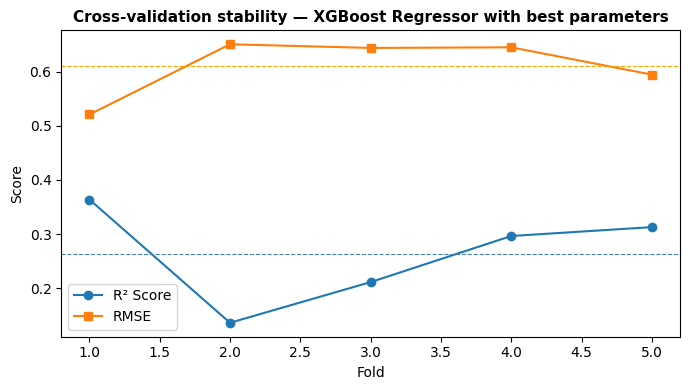


── Final test set performance (Regression) ──
R² Score: 0.383
RMSE: 0.597
MAE: 0.431


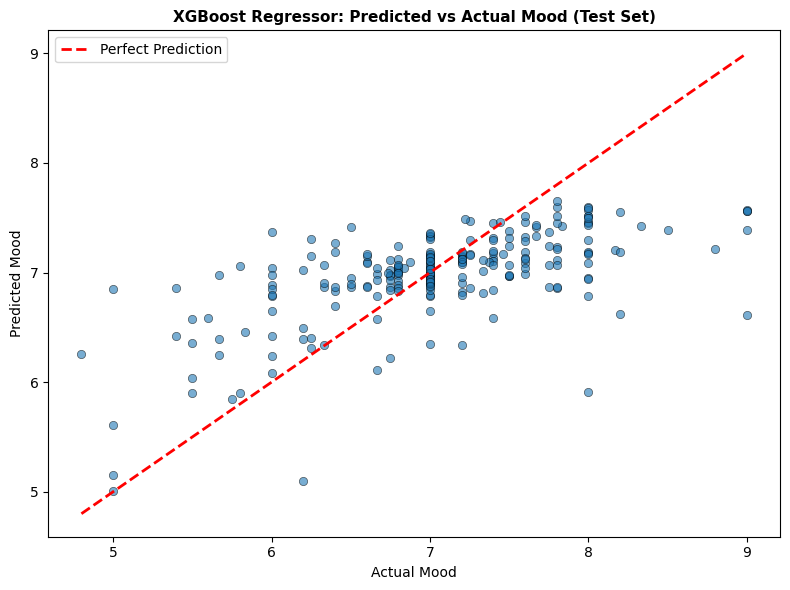

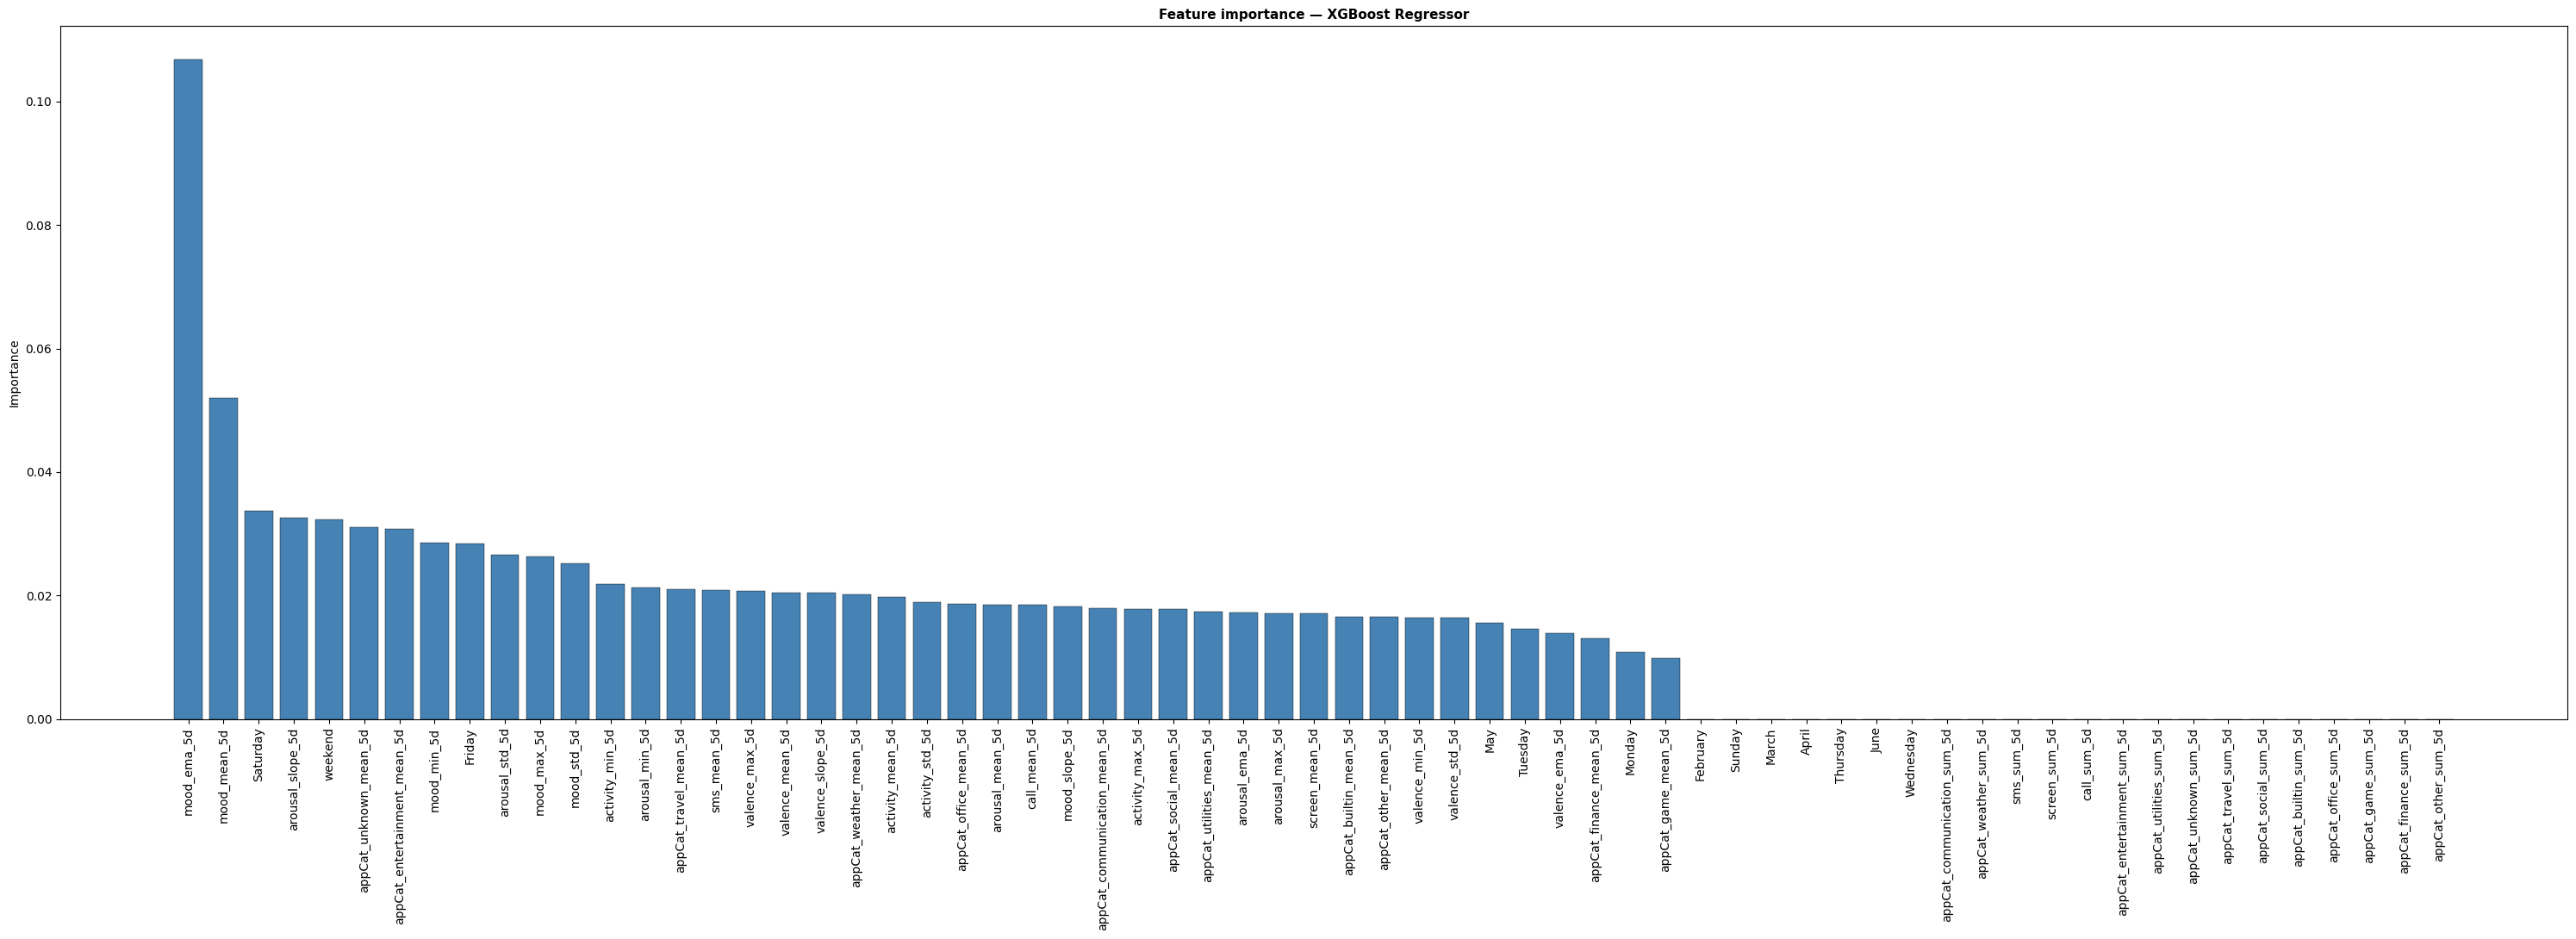

In [174]:
# 4. 5-fold cross-validation with best parameters
# shows stability in each fold - checks if the performance is the same on all time periods
best_params = {k.replace('model__', ''): v for k, v in random_search.best_params_.items()}

fold_scores = {'r2': [], 'rmse': [], 'mae': []}

for fold, (tr_idx, val_idx) in enumerate(custom_cv):
    X_tr  = X_train_full.iloc[tr_idx]
    X_val = X_train_full.iloc[val_idx]
    y_tr  = y_train_full.iloc[tr_idx]
    y_val = y_train_full.iloc[val_idx]

    # scaler - separate inside each fold so validation statistics never leak into training
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    fold_model = xgb.XGBRegressor(
        **best_params,
        objective='reg:squarederror',
        eval_metric='rmse',
        random_state=1
    )
    fold_model.fit(X_tr_scaled, y_tr)
    y_val_pred = fold_model.predict(X_val_scaled)

    # Regression metrics
    fold_r2 = r2_score(y_val, y_val_pred)
    fold_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    fold_mae = mean_absolute_error(y_val, y_val_pred)
    
    fold_scores['r2'].append(fold_r2)
    fold_scores['rmse'].append(fold_rmse)
    fold_scores['mae'].append(fold_mae)
    print(f"Fold {fold+1} — R²: {fold_r2:.3f} RMSE: {fold_rmse:.3f} MAE: {fold_mae:.3f}")

print(f"\nMean R²: {np.mean(fold_scores['r2']):.3f} ± {np.std(fold_scores['r2']):.3f}")
print(f"Mean RMSE: {np.mean(fold_scores['rmse']):.3f} ± {np.std(fold_scores['rmse']):.3f}")
print(f"Mean MAE: {np.mean(fold_scores['mae']):.3f} ± {np.std(fold_scores['mae']):.3f}")

# cross-validation fold scores plot (stability)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 6), fold_scores['r2'], marker='o', label='R² Score')
ax.plot(range(1, 6), fold_scores['rmse'], marker='s', label='RMSE')
ax.axhline(np.mean(fold_scores['r2']), linestyle='--', color='steelblue', linewidth=0.8)
ax.axhline(np.mean(fold_scores['rmse']), linestyle='--', color='orange', linewidth=0.8)
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Cross-validation stability — XGBoost Regressor with best parameters')
ax.legend()
plt.tight_layout()
plt.show()

# 5. retrain final model on full training set
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_full)
X_test_scaled = scaler_final.transform(X_test)

final_model = xgb.XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    eval_metric='rmse',
    random_state=1
)

final_model.fit(X_train_scaled, y_train_full)

# 6. final evaluation on test set
y_pred = final_model.predict(X_test_scaled)

print("\n── Final test set performance (Regression) ──")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")

# Prediction vs actual plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolor='k', linewidth=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Mood')
ax.set_ylabel('Predicted Mood')
ax.set_title('XGBoost Regressor: Predicted vs Actual Mood (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

# Feature importance
importance_df = pd.DataFrame({'feature': X.columns, 'importance': final_model.feature_importances_}).sort_values('importance', ascending=False)
fig, ax = plt.subplots(figsize=(30, 11))
ax.bar(importance_df['feature'], importance_df['importance'], color='steelblue', edgecolor='k', linewidth=0.3)
ax.set_ylabel('Importance')
ax.set_title('Feature importance — XGBoost Regressor')
ax.tick_params(axis='x', rotation=90, labelsize=10)
plt.tight_layout()
plt.show()

### b) RNN - temporal